# Credit-Card Fraud Detection on BankSim
### An end-to-end, critically evaluated machine-learning workflow

**Dataset:** BankSim synthetic payments (594,643 transactions · 180 daily steps · 7,200 frauds)
**Models:** Logistic Regression · Decision Tree · Random Forest · Gradient Boosting (4 models, plus 2 naive baselines for reference)
**Primary metric:** PR-AUC (Average Precision) plus a **cost-based** business metric, not accuracy.

## Executive summary

**Problem.** Detect the 1.21% of BankSim payments that are fraudulent (7,200 of 594,643) and quantify the business value of doing so.

**Approach.** Leakage-safe, chronological design: train on days 0-119, tune on 120-149, report once on 150-179. Four models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting), two naive baselines, causal customer-history features, day-block bootstrap for uncertainty, and a cost-based business metric.

**Headline results (test window, 1,200 frauds, thresholds fixed on validation)**

| Model | PR-AUC [95% CI] | Precision | Recall | Alerts | $ saved |
|---|---|---|---|---|---|
| **Gradient Boosting** | **0.956** [0.949, 0.963] | 0.910 | 0.860 | 1,900 | $590.6k |
| Random Forest | 0.928 [0.920, 0.939] | 0.881 | 0.837 | 1,875 | $589.4k |
| Logistic Regression | 0.922 [0.911, 0.934] | 0.848 | 0.838 | 2,046 | $589.5k |
| Decision Tree | 0.878 [0.866, 0.894] | 0.864 | 0.781 | 2,248 | $584.9k |
| *Baseline: amount only* | *0.704* | *0.769* | *0.592* | *3,520* | *$573.7k* |
| *Baseline: category prior* | *0.464* | *0.555* | *0.508* | *8,533* | *$549.9k* |

**What matters most**
1. **Gradient Boosting is the best model, and the ranking is statistically solid** (it wins in 100% of bootstrap resamples), but its *dollar* advantage over Logistic Regression or Random Forest is only about $1.2k on ~$601k of fraud, i.e. 0.2% of losses. The model choice is a refinement; the big win is having *any* decent model.
2. **A one-line rule already saves 95%** of fraud value. ML earns its keep through far fewer false alerts, and by catching smaller-ticket fraud.
3. **Merchant identity drives the model** (ablation: -0.065 PR-AUC without it). In this simulator that is likely an artefact of how thieves were injected, so real-world performance should be expected to be lower.
4. **Customer-history features help consistently** (+0.02 to +0.03 PR-AUC for every model); **age and gender add nothing** and should be removed (it also narrows the female/male false-positive gap).
5. **No sign of leakage or time-instability** in the simulation, but the data are stationary by construction (exactly 40 frauds every day), so this cannot validate robustness to drift.

## Table of contents
1. Setup and configuration
2. Data loading, cleaning and audit
3. Exploratory data analysis (with statistical checks)
4. Leakage-safe feature engineering
5. Validation design (chronological split)
6. Evaluation framework (metrics, baselines, business cost)
7. Modelling: feature-set experiment, tuning, final fit
8. Test-set evaluation with uncertainty
9. Critical analysis: hard subset, errors, explainability, calibration, stability, fairness, ablations, cost sensitivity
10. Conclusions, limitations and recommendations

> **How to read this notebook.** Every section ends with a short *Critical reading* note. These notes separate what the data *shows* from what it merely *suggests*, and flag where a result could be an artefact of the simulation. Set `QUICK_RUN=1` in the environment for a fast smoke test on a sample of customers.

## 1. Setup and configuration

In [17]:
import os, time, warnings
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             roc_curve, precision_score, recall_score, f1_score,
                             matthews_corrcoef, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
QUICK_RUN = os.environ.get("QUICK_RUN", "0") == "1"   
REVIEW_COST = 5.0         
TRAIN_END, VAL_END = 120, 150   
N_BOOT = 10 if QUICK_RUN else 100

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12})
C_LEGIT, C_FRAUD = "#4C78A8", "#E4572E"
MODEL_COLORS = {"Logistic Regression": "#7F7F7F", "Decision Tree": "#2CA02C",
                "Random Forest": "#1F77B4", "Gradient Boosting": "#E4572E",
                "Baseline: category prior": "#BBBBBB", "Baseline: amount only": "#DDDDDD"}
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)
print("QUICK_RUN:", QUICK_RUN)

numpy 1.26.4 | pandas 2.3.3 | scikit-learn 1.9.1
QUICK_RUN: False


## 2. Data loading, cleaning and audit

Decisions taken here, so they are explicit and reviewable:

| Item | Decision | Reason |
|---|---|---|
| String quoting (`'C123'`) | stripped | The CSV wraps every string in single quotes. |
| `zipcodeOri`, `zipMerchant` | dropped after asserting they are constant | Zero information. |
| `age = 'U'` | recoded to **7** (as requested) | Missingness is systematic (see audit: `U` ⇔ gender `E`). |
| `es_` prefix in `category` | removed | Readability only. |
| `step` | **kept, but never used as a predictor** | The brief says `step` was removed, but it is present in the file. It is needed for a chronological split and for causal, history-based features. |

In [18]:
DATA_PATH = 'bs140513_032310.csv'
raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head())

Loaded bs140513_032310.csv: 594,643 rows x 10 columns


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.5500,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.6800,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.8900,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.2500,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.7200,0


In [19]:
df = raw.copy()
for c in ["customer", "age", "gender", "zipcodeOri", "merchant", "zipMerchant", "category"]:
    df[c] = df[c].astype(str).str.strip("'")

assert df.step.is_monotonic_increasing, "rows are expected to be in chronological order"
print("zip columns -> unique values:", df.zipcodeOri.unique(), df.zipMerchant.unique())
assert df.zipcodeOri.nunique() == 1 and df.zipMerchant.nunique() == 1
df = df.drop(columns=["zipcodeOri", "zipMerchant"])

df["category"] = df.category.str.replace("es_", "", regex=False)
df["age"] = df.age.replace({"U": "7"}).astype(int)
AGE_LABELS = {0: "<=18", 1: "19-25", 2: "26-35", 3: "36-45", 4: "46-55", 5: "56-65", 6: ">65", 7: "Unknown"}

if QUICK_RUN:   
    keep = np.random.default_rng(SEED).choice(df.customer.unique(), size=700, replace=False)
    df = df[df.customer.isin(keep)]
df = df.reset_index(drop=True)
df.dtypes.to_frame("dtype").T

zip columns -> unique values: ['28007'] ['28007']


,step,customer,age,gender,merchant,category,amount,fraud
dtype,int64,object,int32,object,object,object,float64,int64


In [20]:
cust_attr = df.groupby("customer")[["age", "gender"]].nunique()
mer_cat = df.groupby("merchant").category.nunique()
checks = [
    ("Rows", f"{len(df):,}"),
    ("Missing values (all columns)", int(df.isna().sum().sum())),
    ("Exact duplicate rows", int(df.duplicated().sum())),
    ("Steps (days)", f"{df.step.nunique()}  ({df.step.min()}-{df.step.max()})"),
    ("Unique customers (brief says 4,109)", f"{df.customer.nunique():,}"),
    ("Unique merchants / categories", f"{df.merchant.nunique()} / {df.category.nunique()}"),
    ("Every customer has exactly one age and one gender", bool((cust_attr <= 1).all().all())),
    ("Every merchant belongs to exactly one category", bool((mer_cat == 1).all())),
    ("Age==7 (Unknown)  <=>  gender=='E' (Enterprise)", bool((df.age.eq(7) == df.gender.eq("E")).all())),
    ("Zero-amount transactions (fraud among them)", f"{int((df.amount == 0).sum())}  ({int(df.loc[df.amount == 0, 'fraud'].sum())})"),
    ("Amount min / median / max", f"{df.amount.min():.2f} / {df.amount.median():.2f} / {df.amount.max():,.2f}"),
    ("Fraud transactions / prevalence", f"{int(df.fraud.sum()):,} / {df.fraud.mean():.3%}"),
]
pd.DataFrame(checks, columns=["check", "result"]).set_index("check")

,result
check,
Rows,"594,643"
Missing values (all columns),0
Exact duplicate rows,0
Steps (days),180 (0-179)
"Unique customers (brief says 4,109)","4,112"
Unique merchants / categories,50 / 15
Every customer has exactly one age and one gender,True
Every merchant belongs to exactly one category,True
Age==7 (Unknown) <=> gender=='E' (Enterprise),True


**Critical reading.**
* The data are clean (no missing values, no duplicates), which is itself a warning: real transaction data never are.
* Two discrepancies with the brief: `step` **is** in the file, and there are **4,112** customers (brief: 4,109). Neither affects modelling, but it is the kind of mismatch that should be reported to the data owner.
* `Age = 7` is perfectly redundant with `Gender = 'E'`; the "systematic missingness" is a structural fact, not a data-quality issue. Recoding to 7 is harmless for trees, but would be wrong as an ordinal number in a linear model, so Logistic Regression one-hot encodes age.
* The 52 zero-amount rows are all legitimate, so they carry no fraud signal.

## 3. Exploratory data analysis

Every visual claim below is backed by a number or a statistical test, and each block asks: *what would this imply for a real bank, and what is merely a property of the simulator?*

### 3.1 Target imbalance

Fraud prevalence: 1.211%  (1 in 83 transactions)
Accuracy of a model that always says 'legit': 98.789%  -> accuracy is useless here
Frauds are 1.21% of transactions but 17.0% of total transaction VALUE


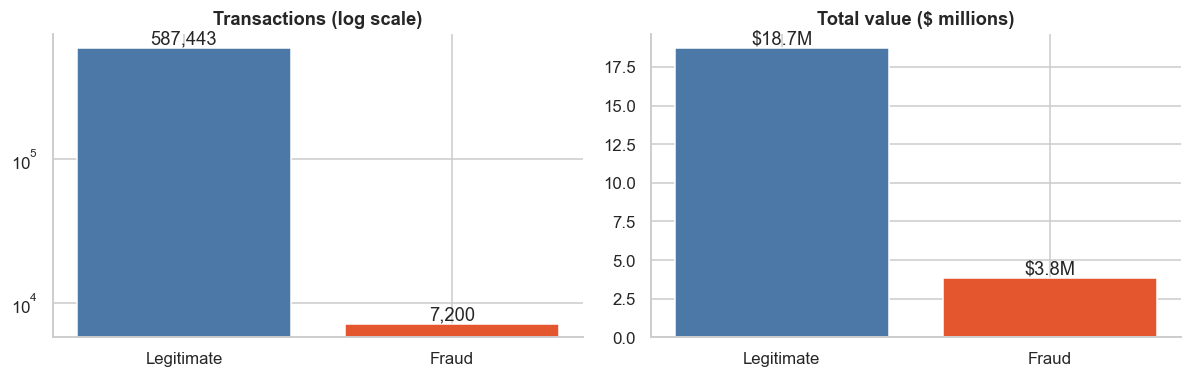

In [21]:
n_fraud, prev = int(df.fraud.sum()), df.fraud.mean()
value_share = df.loc[df.fraud == 1, "amount"].sum() / df.amount.sum()
print(f"Fraud prevalence: {prev:.3%}  (1 in {1/prev:,.0f} transactions)")
print(f"Accuracy of a model that always says 'legit': {1-prev:.3%}  -> accuracy is useless here")
print(f"Frauds are {prev:.2%} of transactions but {value_share:.1%} of total transaction VALUE")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
counts = df.fraud.map({0: "Legitimate", 1: "Fraud"}).value_counts().reindex(["Legitimate", "Fraud"])
ax[0].bar(counts.index, counts.values, color=[C_LEGIT, C_FRAUD]); ax[0].set_yscale("log")
ax[0].set_title("Transactions (log scale)")
for i, v in enumerate(counts.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")
val = (df.groupby("fraud").amount.sum() / 1e6).rename({0: "Legitimate", 1: "Fraud"}).reindex(["Legitimate", "Fraud"])
ax[1].bar(val.index, val.values, color=[C_LEGIT, C_FRAUD]); ax[1].set_title("Total value ($ millions)")
for i, v in enumerate(val.values): ax[1].text(i, v, f"${v:,.1f}M", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 3.2 Time structure

Distinct daily fraud counts: [40] (std of daily fraud rate: 0.0015)


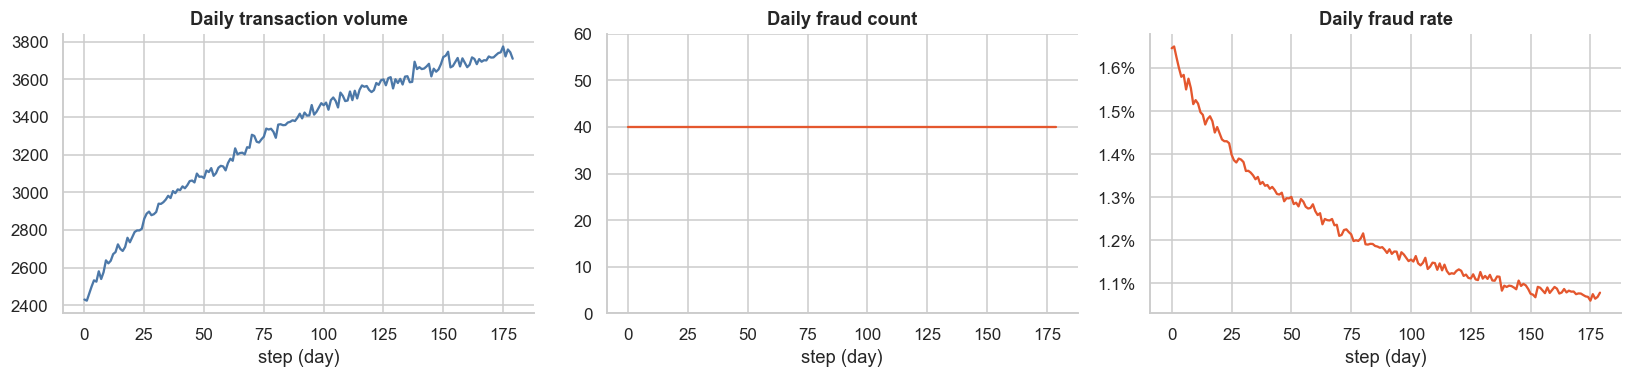

In [22]:
daily = df.groupby("step").agg(n_txn=("fraud", "size"), n_fraud=("fraud", "sum"), value=("amount", "sum"))
daily["fraud_rate"] = daily.n_fraud / daily.n_txn
print("Distinct daily fraud counts:", sorted(daily.n_fraud.unique()), "(std of daily fraud rate: "
      f"{daily.fraud_rate.std():.4f})")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(daily.index, daily.n_txn, color=C_LEGIT); ax[0].set_title("Daily transaction volume")
ax[1].plot(daily.index, daily.n_fraud, color=C_FRAUD); ax[1].set_ylim(0, max(60, daily.n_fraud.max() * 1.3))
ax[1].set_title("Daily fraud count")
ax[2].plot(daily.index, daily.fraud_rate, color=C_FRAUD); ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1, 1))
ax[2].set_title("Daily fraud rate")
for a in ax: a.set_xlabel("step (day)")
plt.tight_layout(); plt.show()

**Critical reading.** The fraud count is *exactly* 40 on all 180 days. Real fraud is bursty, seasonal and adaptive. Consequences: (1) the daily fraud *rate* moves only because legitimate volume moves; (2) there is no concept drift to detect, so stability results later in this notebook are **necessary but not sufficient** evidence of robustness; (3) the `step` column has no genuine predictive value and is rightly excluded from the features.

### 3.3 Merchant category

,n,frauds,fraud_rate,share_of_txns,share_of_frauds,median_amt_legit,median_amt_fraud
category,,,,,,,
leisure,499,474,94.99%,0.08%,6.58%,$73.31,$300.59
travel,728,578,79.40%,0.12%,8.03%,$601.88,"$2,432.65"
sportsandtoys,"4,002","1,982",49.53%,0.67%,27.53%,$78.73,$311.42
hotelservices,"1,744",548,31.42%,0.29%,7.61%,$100.39,$382.49
otherservices,912,228,25.00%,0.15%,3.17%,$65.80,$272.18
home,"1,986",302,15.21%,0.33%,4.19%,$97.71,$391.67
health,"16,133","1,696",10.51%,2.71%,23.56%,$89.11,$353.37
tech,"2,370",158,6.67%,0.40%,2.19%,$84.22,$364.43
wellnessandbeauty,"15,086",718,4.76%,2.54%,9.97%,$49.96,$198.32



Categories with ZERO fraud: ['contents', 'food', 'transportation']
They hold 89.5% of all transactions -> trivially 'easy negatives'


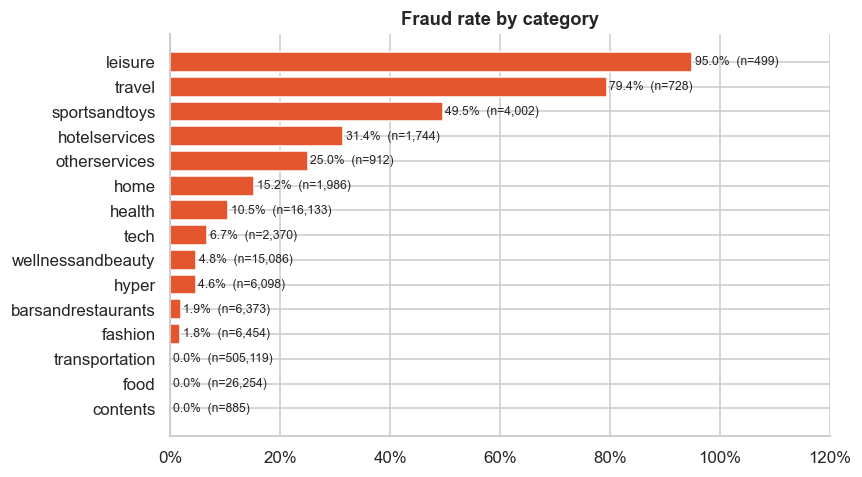

In [23]:
cat_tbl = df.groupby("category").agg(n=("fraud", "size"), frauds=("fraud", "sum"), fraud_rate=("fraud", "mean"))
cat_tbl["share_of_txns"] = cat_tbl.n / cat_tbl.n.sum()
cat_tbl["share_of_frauds"] = cat_tbl.frauds / cat_tbl.frauds.sum()
cat_tbl["median_amt_legit"] = df[df.fraud == 0].groupby("category").amount.median()
cat_tbl["median_amt_fraud"] = df[df.fraud == 1].groupby("category").amount.median()
cat_tbl = cat_tbl.sort_values("fraud_rate", ascending=False)
display(cat_tbl.style.format({"n": "{:,.0f}", "frauds": "{:,.0f}", "fraud_rate": "{:.2%}", "share_of_txns": "{:.2%}",
                              "share_of_frauds": "{:.2%}", "median_amt_legit": "${:,.2f}", "median_amt_fraud": "${:,.2f}"})
        .bar(subset=["fraud_rate"], color="#F01212"))

ZERO_CATS = list(cat_tbl.index[cat_tbl.frauds == 0])
print(f"\nCategories with ZERO fraud: {ZERO_CATS}")
print(f"They hold {cat_tbl.loc[ZERO_CATS, 'share_of_txns'].sum():.1%} of all transactions -> trivially 'easy negatives'")

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = cat_tbl.sort_values("fraud_rate")
ax.barh(plot_df.index, plot_df.fraud_rate, color=C_FRAUD)
for y, (r, n) in enumerate(zip(plot_df.fraud_rate, plot_df.n)):
    ax.text(r + 0.005, y, f"{r:.1%}  (n={n:,})", va="center", fontsize=8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax.set_xlim(0, 1.2)
ax.set_title("Fraud rate by category"); plt.tight_layout(); plt.show()

**Critical reading.**
* Fraud is concentrated in a few categories: leisure (95%) and travel (79%) are almost always fraud when they occur, sports & toys is ~50%, while transportation, food and contents have **zero** fraud.
* The three zero-fraud categories contain **89.5%** of all transactions. A model that merely knows the category already separates most of the data, and it inflates ROC-AUC. This is why PR-AUC, the cost metric and a hard-subset analysis (9.1) are used.
* Share of volume and share of fraud differ sharply: health + sports & toys alone hold ~51% of all frauds from only ~3% of transactions.
* The fraud-rate-by-category chart conflates "risky category" with "small category" (leisure n=499, travel n=728). High rates there are real in this dataset but estimated from few rows.

### 3.4 Transaction amount

Amount alone: ROC-AUC = 0.949  (Mann-Whitney p = 0.0e+00)
             count     mean      std    min      25%      50%      75%  \
fraud                                                                    
legit 587,443.0000  31.8500  31.4700 0.0000  13.5900  26.6100  41.9000   
fraud   7,200.0000 530.9300 835.5900 0.0300 159.9800 319.1800 548.9800   

             max  
fraud             
legit 2,144.8600  
fraud 8,329.9600  

Does amount still separate fraud INSIDE a category?  (controls for category confounding)


,median_legit,median_fraud,amount_only_AUC_within_category,fraud/legit median ratio
category,,,,
leisure,73.3100,300.5900,0.9954,4.1003
otherservices,65.7950,272.1750,0.8773,4.1367
tech,84.2250,364.4300,0.8727,4.3269
home,97.7100,391.6700,0.8661,4.0085
travel,601.8850,"2,432.6500",0.8648,4.0417
hyper,35.4150,163.7850,0.8571,4.6247
hotelservices,100.3850,382.4900,0.8553,3.8102
fashion,54.8700,224.6850,0.8531,4.0949
sportsandtoys,78.7350,311.4200,0.8530,3.9553


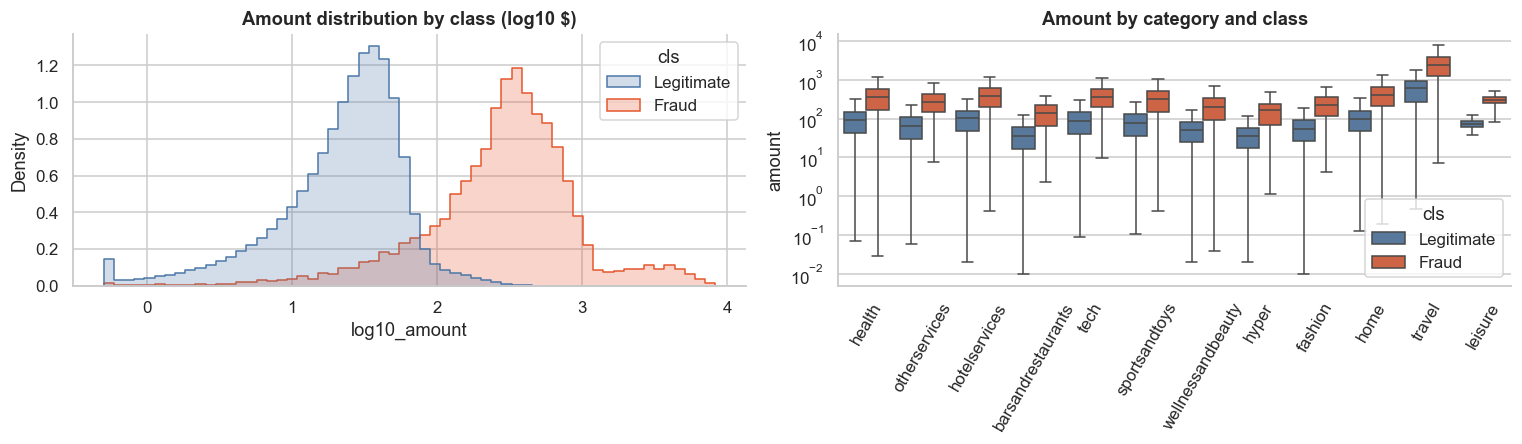

In [24]:
overall_auc = roc_auc_score(df.fraud, df.amount)
u = stats.mannwhitneyu(df.loc[df.fraud == 1, "amount"], df.loc[df.fraud == 0, "amount"])
print(f"Amount alone: ROC-AUC = {overall_auc:.3f}  (Mann-Whitney p = {u.pvalue:.1e})")
print(df.groupby("fraud").amount.describe().rename(index={0: "legit", 1: "fraud"}).round(2))

RISKY_ALL = list(cat_tbl.index[cat_tbl.frauds >= 100])
rows = []
for c in RISKY_ALL:
    g = df[df.category == c]
    rows.append({"category": c, "median_legit": g[g.fraud == 0].amount.median(),
                 "median_fraud": g[g.fraud == 1].amount.median(),
                 "amount_only_AUC_within_category": roc_auc_score(g.fraud, g.amount)})
within = pd.DataFrame(rows).set_index("category")
within["fraud/legit median ratio"] = within.median_fraud / within.median_legit
print("\nDoes amount still separate fraud INSIDE a category?  (controls for category confounding)")
display(within.sort_values("amount_only_AUC_within_category", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
d2 = df.assign(log10_amount=np.log10(df.amount.clip(lower=0.5)), cls=df.fraud.map({0: "Legitimate", 1: "Fraud"}))
sns.histplot(data=d2, x="log10_amount", hue="cls", stat="density", common_norm=False, element="step",
             bins=60, palette={"Legitimate": C_LEGIT, "Fraud": C_FRAUD}, ax=ax[0])
ax[0].set_title("Amount distribution by class (log10 $)")
sns.boxplot(data=d2[d2.category.isin(RISKY_ALL)], x="category", y="amount", hue="cls", showfliers=False,
            palette={"Legitimate": C_LEGIT, "Fraud": C_FRAUD}, ax=ax[1])
ax[1].set_yscale("log"); ax[1].tick_params(axis="x", rotation=60); ax[1].set_title("Amount by category and class")
ax[1].set_xlabel(""); plt.tight_layout(); plt.show()

**Critical reading.**
* Amount alone has ROC-AUC 0.949, and **inside** every at-risk category the typical fraud is roughly 4x the legitimate median (within-category AUC from ~0.84 to ~0.99). So amount is not just a proxy for category: it is an independent signal.
* The mechanism looks simulator-driven (thieves buy expensive things). Real fraudsters often do the opposite, probing with small "card-testing" amounts. A model that learned "big = fraud" would miss that behaviour entirely; keep this in mind for deployment.
* The class overlap in amount (legit tail up to $2,145, fraud median $319) is why a simple threshold rule is strong but not sufficient.

### 3.5 Demographics, and a confounding check

,levels,Cramers_V,chi2_p
feature,,,
category,15,0.571,0.0e+00
merchant,50,0.732,0.0e+00
age,8,0.009,2.0e-07
gender,4,0.026,5.9e-85


Gender


,n,raw_fraud_rate,share_in_zero_fraud_cats,fraud_rate_in_at_risk_cats
gender,,,,
E,"1,178",0.59%,88.5%,5.19%
F,"324,565",1.47%,89.1%,13.46%
M,"268,385",0.91%,90.0%,9.06%
U,515,0.00%,91.5%,0.00%


Age


,n,raw_fraud_rate,share_in_zero_fraud_cats,fraud_rate_in_at_risk_cats
age,,,,
<=18,"2,452",1.96%,85.1%,13.15%
19-25,"58,131",1.19%,89.7%,11.51%
26-35,"187,310",1.25%,89.4%,11.85%
36-45,"147,131",1.19%,89.5%,11.36%
46-55,"109,025",1.29%,89.3%,12.10%
56-65,"62,642",1.10%,90.0%,10.99%
>65,"26,774",0.97%,89.7%,9.43%
Unknown,"1,178",0.59%,88.5%,5.19%


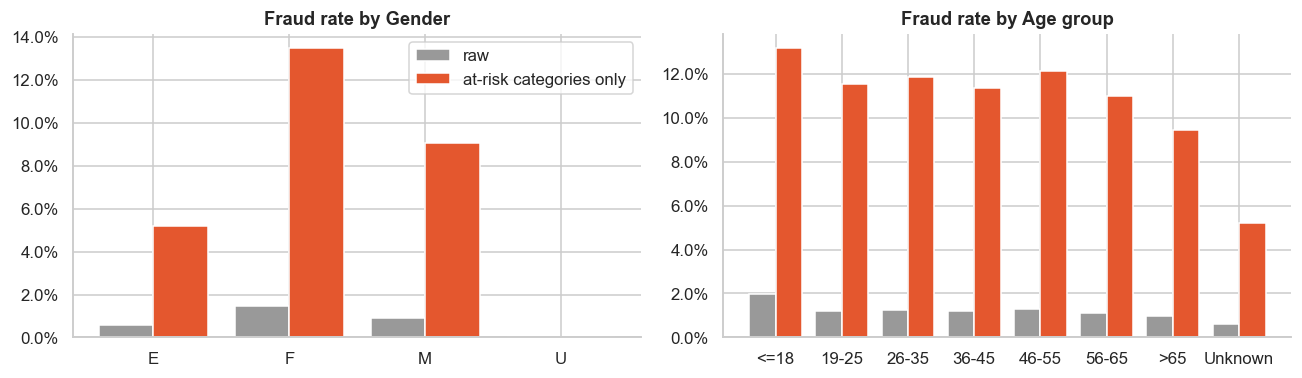

In [25]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum(); k = min(ct.shape) - 1
    return float(np.sqrt(chi2 / (n * k))), float(p)

rows = []
for c in ["category", "merchant", "age", "gender"]:
    v, p = cramers_v(df[c], df.fraud); rows.append({"feature": c, "levels": df[c].nunique(), "Cramers_V": v, "chi2_p": p})
display(pd.DataFrame(rows).set_index("feature").style.format({"Cramers_V": "{:.3f}", "chi2_p": "{:.1e}"}))

df["_zero_cat"] = df.category.isin(ZERO_CATS)
def demo_table(col):
    g = df.groupby(col)
    t = pd.DataFrame({"n": g.size(), "raw_fraud_rate": g.fraud.mean(), "share_in_zero_fraud_cats": g._zero_cat.mean()})
    t["fraud_rate_in_at_risk_cats"] = df[~df._zero_cat].groupby(col).fraud.mean()
    return t
gender_t, age_t = demo_table("gender"), demo_table("age").rename(index=AGE_LABELS)
fmt = {"n": "{:,.0f}", "raw_fraud_rate": "{:.2%}", "share_in_zero_fraud_cats": "{:.1%}", "fraud_rate_in_at_risk_cats": "{:.2%}"}
print("Gender"); display(gender_t.style.format(fmt))
print("Age");    display(age_t.style.format(fmt))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, t, title in [(ax[0], gender_t, "Gender"), (ax[1], age_t, "Age group")]:
    x = np.arange(len(t)); w = 0.4
    a.bar(x - w/2, t.raw_fraud_rate, w, label="raw", color="#999999")
    a.bar(x + w/2, t.fraud_rate_in_at_risk_cats, w, label="at-risk categories only", color=C_FRAUD)
    a.set_xticks(x); a.set_xticklabels(t.index); a.yaxis.set_major_formatter(mtick.PercentFormatter(1, 1)); a.set_title(f"Fraud rate by {title}")
ax[0].legend(); plt.tight_layout(); plt.show()
df = df.drop(columns="_zero_cat")

**Critical reading.**
* Age is practically irrelevant (Cramér's V = 0.009). Gender is statistically significant (p ~ 1e-85 with 594k rows) but small (V = 0.026). With this much data, *significance is not importance*.
* **Confounding check:** all genders sit ~89-92% in zero-fraud categories, so category mix does **not** explain the female/male gap (13.5% vs 9.1% fraud rate inside at-risk categories). The gap is real in this data, but the cause is unknown (it could be which cards the simulated thieves targeted); a model must not turn that into a rule about who is "riskier".
* The 'U' gender group (515 rows) has zero fraud, and Enterprise is low; both are tiny, so no conclusions should be drawn.
* Age group 0 (<=18) shows the highest raw rate but rests on only 48 frauds in 2,452 rows.

### 3.6 Merchants

Top merchants by fraud rate (n>=100):


,category,n,frauds,rate,category_rate,excess_vs_category
merchant,,,,,,
M1294758098,leisure,191,184,96.3%,95.0%,+1.3%
M3697346,leisure,308,290,94.2%,95.0%,-0.8%
M1873032707,hotelservices,250,216,86.4%,31.4%,+55.0%
M732195782,travel,608,518,85.2%,79.4%,+5.8%
M980657600,sportsandtoys,"1,769",1472,83.2%,49.5%,+33.7%
M857378720,hotelservices,122,92,75.4%,31.4%,+44.0%
M2011752106,hotelservices,244,166,68.0%,31.4%,+36.6%
M17379832,sportsandtoys,282,178,63.1%,49.5%,+13.6%



Within a category, does the merchant still matter?  (chi-square of merchant x fraud)


,merchants,chi2_p_merchant_effect
category,,
fashion,3,1.6e-149
health,5,0.0e+00
home,5,1.4e-172
hotelservices,7,1.3e-247
leisure,2,3.8e-01
sportsandtoys,6,0.0e+00
tech,3,3.1e-26
travel,4,2.2e-23
wellnessandbeauty,7,0.0e+00


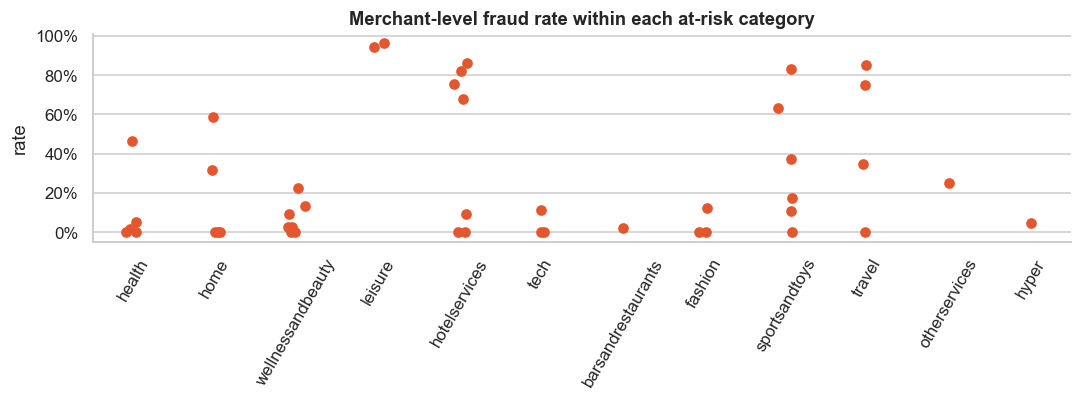

In [26]:
mer = df.groupby("merchant").agg(category=("category", "first"), n=("fraud", "size"), frauds=("fraud", "sum"), rate=("fraud", "mean"))
mer["category_rate"] = mer.category.map(cat_tbl.fraud_rate)
mer["excess_vs_category"] = mer.rate - mer.category_rate
print("Top merchants by fraud rate (n>=100):")
display(mer[mer.n >= 100].sort_values("rate", ascending=False).head(8).style.format(
    {"n": "{:,.0f}", "rate": "{:.1%}", "category_rate": "{:.1%}", "excess_vs_category": "{:+.1%}"}))

rows = []
for c, g in df[~df.category.isin(ZERO_CATS)].groupby("category"):
    ct = pd.crosstab(g.merchant, g.fraud)
    if ct.shape[0] > 1 and ct.shape[1] == 2:
        chi2, p, _, _ = stats.chi2_contingency(ct); rows.append({"category": c, "merchants": ct.shape[0], "chi2_p_merchant_effect": p})
print("\nWithin a category, does the merchant still matter?  (chi-square of merchant x fraud)")
display(pd.DataFrame(rows).set_index("category").style.format({"chi2_p_merchant_effect": "{:.1e}"}))

fig, ax = plt.subplots(figsize=(10, 3.8))
m2 = mer[~mer.category.isin(ZERO_CATS)]
sns.stripplot(data=m2, x="category", y="rate", size=7, color=C_FRAUD, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax.tick_params(axis="x", rotation=60)
ax.set_title("Merchant-level fraud rate within each at-risk category"); ax.set_xlabel(""); plt.tight_layout(); plt.show()

**Critical reading.**
* Merchant ID is more associated with fraud (V = 0.73) than category (V = 0.57), and the effect persists **within** categories: for 8 of 9 multi-merchant at-risk categories the merchant effect is highly significant (leisure, with only two merchants, is the exception). E.g. within hotel services one merchant has 86% fraud versus a category average of 31%.
* Each merchant belongs to exactly one category, so merchant is a finer partition of category.
* In practice this is a *risk*: a model that memorises merchant IDs cannot score a new merchant and can be gamed by fraudsters changing merchants. The ablation in 9.7 quantifies the dependence.

### 3.7 Customers and victims

Customers with >=1 fraud: 1,483 of 4,112  (36.1%)
Frauds per victim: {'mean': 4.9, '50%': 2.0, 'max': 144.0}
Days between a victim's first and last fraud: median 50, 90th pct 139


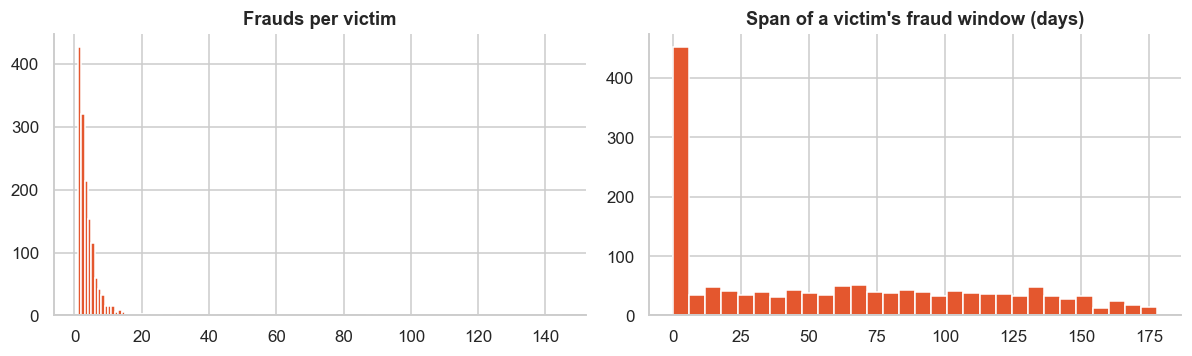

In [27]:
cust = df.groupby("customer").agg(n=("fraud", "size"), frauds=("fraud", "sum"))
victims = cust[cust.frauds > 0]
print(f"Customers with >=1 fraud: {len(victims):,} of {len(cust):,}  ({len(victims)/len(cust):.1%})")
print("Frauds per victim:", victims.frauds.describe()[["mean", "50%", "max"]].round(1).to_dict())
span = df[df.fraud == 1].groupby("customer").step.agg(lambda s: s.max() - s.min())
print(f"Days between a victim's first and last fraud: median {span.median():.0f}, 90th pct {span.quantile(.9):.0f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(victims.frauds, bins=range(1, int(victims.frauds.max()) + 2), color=C_FRAUD); ax[0].set_title("Frauds per victim")
ax[1].hist(span, bins=30, color=C_FRAUD); ax[1].set_title("Span of a victim's fraud window (days)")
plt.tight_layout(); plt.show()

**Critical reading.** 36% of customers (1,483 of 4,112) are victims, with a median of 2 frauds each but a heavy tail (up to 144). Fraud on a victim spans a median of 50 days, so thieves keep using a compromised card rather than striking once. This justifies customer-history features and also warns that a **past-fraud flag** would be very powerful, yet it is deliberately excluded: in production, fraud labels arrive days or weeks later (chargebacks), so using it would leak information that does not exist at decision time.

## 4. Leakage-safe feature engineering

Fraud detection is a **sequential** problem, so it matters what the model is allowed to know at scoring time. Rules applied:

* **Never used as predictors:** `customer` ID (memorisation), `step` (the simulator fixes 40 frauds per step, so it carries no real signal), and any *past-fraud* flag of the customer (in production the label arrives days later, via chargebacks).
* **Causal behavioural features:** each is computed from the customer's *previous* transactions only (`cumcount`, `shift(1)`, expanding statistics). The current row never contributes to its own features.
* **Train-fitted statistics:** category-level mean/std of log-amount are estimated on the **training window only**.
* **No target encoding:** merchant and category are one-hot or natively categorical, which avoids target leakage.

| Feature | Meaning |
|---|---|
| `log_amount` | log(1 + amount) |
| `amt_z_in_category` | how unusual the amount is for that category (train-fitted z-score of log-amount) |
| `log_n_prior_txn`, `is_first_txn` | how much history the customer has |
| `same_day_prior_txn` | velocity: earlier transactions by this customer on the same day |
| `log_amt_to_cust_mean`, `log_amt_to_cust_max` | amount relative to the customer's own history |
| `days_since_last_txn` | recency |
| `is_new_merchant`, `is_new_category` | first time this customer pays this merchant/category (for customers with history) |

In [28]:
def add_behavioural_features(d):
    d = d.copy()                        
    g = d.groupby("customer", sort=False)
    d["n_prior_txn"] = g.cumcount()
    d["is_first_txn"] = (d.n_prior_txn == 0).astype(int)
    d["same_day_prior_txn"] = d.groupby(["customer", "step"], sort=False).cumcount()

    prior_sum = g.amount.cumsum() - d.amount
    prior_mean = prior_sum / d.n_prior_txn.replace(0, np.nan)
    d["log_amt_to_cust_mean"] = np.log((d.amount + 1) / (prior_mean + 1)).fillna(0.0)

    prior_max = g.amount.cummax().groupby(d.customer, sort=False).shift(1)
    d["log_amt_to_cust_max"] = np.log((d.amount + 1) / (prior_max + 1)).fillna(0.0)

    d["days_since_last_txn"] = (d.step - g.step.shift(1)).fillna(0.0)
    d["is_new_merchant"] = ((d.groupby(["customer", "merchant"], sort=False).cumcount() == 0) & (d.n_prior_txn > 0)).astype(int)
    d["is_new_category"] = ((d.groupby(["customer", "category"], sort=False).cumcount() == 0) & (d.n_prior_txn > 0)).astype(int)
    d["log_n_prior_txn"] = np.log1p(d.n_prior_txn)
    d["log_amount"] = np.log1p(d.amount)
    return d

df = add_behavioural_features(df)

probe = df[df.step < 60]
recomputed = add_behavioural_features(raw_probe := df.loc[df.step < 60, ["step", "customer", "age", "gender", "merchant", "category", "amount", "fraud"]])
BEH_COLS = ["log_n_prior_txn", "is_first_txn", "same_day_prior_txn", "log_amt_to_cust_mean", "log_amt_to_cust_max",
            "days_since_last_txn", "is_new_merchant", "is_new_category"]
assert np.allclose(probe[BEH_COLS].values, recomputed[BEH_COLS].values), "causality violated!"
print("Causality check passed: features for steps < 60 are identical when the future is removed.")

cmp_cols = ["log_amount"] + BEH_COLS
display(df.groupby("fraud")[cmp_cols].mean().rename(index={0: "legit", 1: "fraud"}).T)

Causality check passed: features for steps < 60 are identical when the future is removed.


fraud,legit,fraud
log_amount,3.1461,5.6358
log_n_prior_txn,4.0642,3.2725
is_first_txn,0.0067,0.0281
same_day_prior_txn,0.0371,0.3539
log_amt_to_cust_mean,-0.4270,0.7285
log_amt_to_cust_max,-2.0066,-0.9812
days_since_last_txn,1.1693,3.5328
is_new_merchant,0.0671,0.5029
is_new_category,0.0429,0.3517


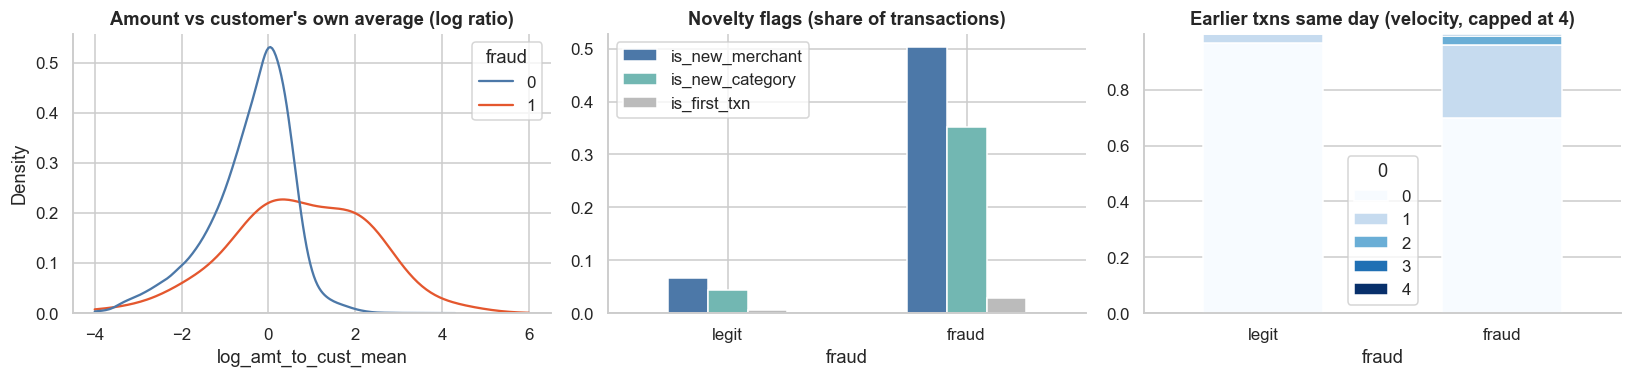

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
sns.kdeplot(data=df.sample(min(150_000, len(df)), random_state=SEED), x="log_amt_to_cust_mean", hue="fraud", common_norm=False,
            palette={0: C_LEGIT, 1: C_FRAUD}, ax=ax[0], bw_adjust=1.5, clip=(-4, 6))
ax[0].set_title("Amount vs customer's own average (log ratio)")
nm = df.groupby("fraud")[["is_new_merchant", "is_new_category", "is_first_txn"]].mean().rename(index={0: "legit", 1: "fraud"})
nm.plot.bar(ax=ax[1], color=["#4C78A8", "#72B7B2", "#BBBBBB"], rot=0); ax[1].set_title("Novelty flags (share of transactions)")
vel = df.groupby("fraud").same_day_prior_txn.apply(lambda s: s.clip(upper=4).value_counts(normalize=True)).unstack().rename(index={0: "legit", 1: "fraud"})
vel.plot.bar(stacked=True, ax=ax[2], cmap="Blues", rot=0); ax[2].set_title("Earlier txns same day (velocity, capped at 4)")
plt.tight_layout(); plt.show()

**Critical reading.**
* Fraudulent transactions are, on average, **above the customer's own norm** (log-ratio +0.73 vs -0.43), go to a **new merchant** about half the time (50% vs 7%), and show far higher same-day velocity (0.35 vs 0.04 earlier transactions).
* The causality test confirms the features use no future information. This is a cheap, high-value safeguard: it would catch a classic bug such as a global `mean()` leaking tomorrow into today.
* Some of these features are correlated (e.g. novelty and ratio-to-mean), which is why ablation (9.7) is more informative than looking at individual means.

## 5. Validation design: chronological split

A random shuffle would let the model train on transactions that happen *after* the ones it is tested on, and it would see the same fraud campaign on both sides. We therefore split by time:

* **Train** = steps 0-119 (fit models)
* **Validation** = steps 120-149 (tune hyper-parameters, choose thresholds, choose feature set)
* **Test** = steps 150-179 (touched **once**, for the final report)

Customers *do* overlap across the splits, which mirrors a real bank (existing customers keep transacting). Section 9.5 additionally stress-tests an *unseen-customer* split.

In [30]:
df["split"] = np.select([df.step < TRAIN_END, df.step < VAL_END], ["train", "val"], default="test")

def fit_cat_stats(train_df):
    return train_df.groupby("category").log_amount.agg(["mean", "std"]).fillna({"std": 1.0})
def apply_amt_z(d, stats_):
    return ((d.log_amount - d.category.map(stats_["mean"])) / d.category.map(stats_["std"]).clip(lower=1e-6)).fillna(0.0)

CAT_STATS = fit_cat_stats(df[df.split == "train"])
df["amt_z_in_category"] = apply_amt_z(df, CAT_STATS)

summary = df.groupby("split").agg(steps=("step", lambda s: f"{s.min()}-{s.max()}"), rows=("fraud", "size"),
                                  frauds=("fraud", "sum"), fraud_rate=("fraud", "mean"), fraud_value=("amount", lambda s: s[df.loc[s.index, "fraud"] == 1].sum()))
display(summary.loc[["train", "val", "test"]].style.format({"rows": "{:,.0f}", "frauds": "{:,.0f}", "fraud_rate": "{:.3%}", "fraud_value": "${:,.0f}"}))

tr_c = set(df.loc[df.split == "train", "customer"])
te = df[df.split == "test"]
print(f"Test transactions from customers seen in training: {te.customer.isin(tr_c).mean():.1%}")
print(f"Test frauds on customers who had NO training history: {(~te[te.fraud == 1].customer.isin(tr_c)).mean():.1%}")

,steps,rows,frauds,fraud_rate,fraud_value
split,,,,,
train,0-119,"374,914","4,800",1.280%,"$2,577,740"
val,120-149,"108,423","1,200",1.107%,"$643,468"
test,150-179,"111,306","1,200",1.078%,"$601,463"


Test transactions from customers seen in training: 100.0%
Test frauds on customers who had NO training history: 0.2%


## 6. Evaluation framework

**Why not accuracy or ROC-AUC alone?** With ~1.2% prevalence and ~89% of rows in categories that never contain fraud, ROC-AUC rewards a model for ranking those easy negatives, so it looks excellent for almost any reasonable model. **PR-AUC (Average Precision)** focuses on the positive class and is our primary threshold-free metric.

**Operating-point metrics** (precision, recall, F1, MCC) are reported at the threshold that maximises F1 on the *validation* set.

**Business cost.** A model is only useful if it saves money:

$$\text{cost} = \underbrace{\sum_{\text{missed frauds}} \text{amount}}_{\text{fraud loss}} \;+\; \underbrace{c_{\text{review}} \times \#\text{alerts}}_{\text{review / friction}}$$

with $c_{\text{review}} = \$5$ as an *assumption* (stress-tested in 9.7). The threshold that minimises this cost on validation is the *deployment* threshold. **Savings** = cost with no model − cost with the model.

**Baselines** that any ML model must beat: (i) *category prior* (score = training fraud-rate of the category), (ii) *amount only* (score = amount).

In [31]:
def cost_opt_threshold(y, p, amt, review_cost):
    order = np.argsort(-p, kind="stable"); ps, ys, am = p[order], y[order], amt[order]
    total_fraud = float((y * amt).sum())
    cost = total_fraud - np.cumsum(ys * am) + review_cost * np.arange(1, len(p) + 1)
    idx = np.flatnonzero(np.r_[ps[1:] != ps[:-1], True])
    j = idx[np.argmin(cost[idx])]
    return (np.inf if cost[j] >= total_fraud else ps[j])

def cost_at(y, p, amt, thr, review_cost):
    alert = p >= thr
    return float((amt * ((~alert) & (y == 1))).sum() + review_cost * alert.sum())

def f1_opt_threshold(y, p):
    P, R, T = precision_recall_curve(y, p)
    f1 = 2 * P[:-1] * R[:-1] / np.clip(P[:-1] + R[:-1], 1e-12, None)
    return T[np.argmax(f1)]

def summarize(name, y, p, amt, f1_thr, cost_thr, is_prob=True, review_cost=REVIEW_COST):
    pred = (p >= f1_thr).astype(int)
    base = float((y * amt).sum()); c = cost_at(y, p, amt, cost_thr, review_cost)
    return {"model": name, "PR_AUC": average_precision_score(y, p), "ROC_AUC": roc_auc_score(y, p),
            "Brier": brier_score_loss(y, np.clip(p, 0, 1)) if is_prob else np.nan,
            "precision": precision_score(y, pred, zero_division=0), "recall": recall_score(y, pred),
            "F1": f1_score(y, pred), "MCC": matthews_corrcoef(y, pred),
            "alerts@cost_thr": int((p >= cost_thr).sum()), "$_loss_no_model": base, "$_cost_with_model": c,
            "$_saved": base - c, "saved_%": (base - c) / base}

FEATURE_COLS_ALL = ["category", "merchant", "gender", "age", "log_amount", "amt_z_in_category"] + BEH_COLS
STATIC_FEATS = ["category", "merchant", "gender", "age", "log_amount", "amt_z_in_category"]
STATIC_BEH_FEATS = FEATURE_COLS_ALL
CAT_COLS = ["category", "merchant", "gender"]

D = {s: df[df.split == s] for s in ["train", "val", "test"]}
y_tr, y_va, y_te = (D[s].fraud.values for s in ["train", "val", "test"])
amt_va, amt_te = D["val"].amount.values, D["test"].amount.values

def make_pipe(kind, feats, params):
    cats = [c for c in CAT_COLS if c in feats]; nums = [c for c in feats if c not in CAT_COLS]
    if kind == "lr":                     
        cats_lr = cats + (["age"] if "age" in nums else []); nums_lr = [c for c in nums if c != "age"]
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32), cats_lr),
                                 ("num", StandardScaler(), nums_lr)])
        clf = LogisticRegression(max_iter=500, random_state=SEED, **params)
    elif kind in ("dt", "rf"):
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32), cats),
                                 ("num", "passthrough", nums)])
        clf = (DecisionTreeClassifier(random_state=SEED, **params) if kind == "dt"
               else RandomForestClassifier(n_jobs=-1, random_state=SEED, **params))
    elif kind == "hgb":
        pre = ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.float32), cats),
                                 ("num", "passthrough", nums)])
        clf = HistGradientBoostingClassifier(categorical_features=list(range(len(cats))), random_state=SEED, **params)
    return Pipeline([("pre", pre), ("clf", clf)])

print("Splits ready:", {k: len(v) for k, v in D.items()})

Splits ready: {'train': 374914, 'val': 108423, 'test': 111306}


## 7. Modelling

Four model families, chosen to cover a bias-variance spectrum and different inductive biases:

| Model | Why it is here | Main risk |
|---|---|---|
| **Logistic Regression** | transparent linear baseline; coefficients are auditable | cannot represent interactions (category x amount) without manual features |
| **Decision Tree** | human-readable rules; fast | high variance, unstable |
| **Random Forest** | variance-reduced non-linear model; strong default | probabilities are compressed; slower scoring |
| **Gradient Boosting** | usually best on tabular data; native categorical handling | more hyper-parameters; can over-fit noise |

*Why not more?* A fifth model (XGBoost/LightGBM) would be near-identical to histogram gradient boosting; k-NN and kernel SVM scale poorly to 400k rows with mixed categorical features. Four well-tuned, well-understood models give a cleaner comparison than five redundant ones.

### 7.1 Experiment 1: do behavioural features help?

Same default hyper-parameters, two feature sets, scored on the validation window. This guards against the common mistake of assuming that more features always help.

feature_set,static only,static + behavioural,gain
model,,,
Decision Tree,0.8374,0.8547,0.0174
Gradient Boosting,0.9204,0.9423,0.0219
Logistic Regression,0.8893,0.9154,0.0262
Random Forest,0.8827,0.9019,0.0191


Feature set carried forward: static + behavioural


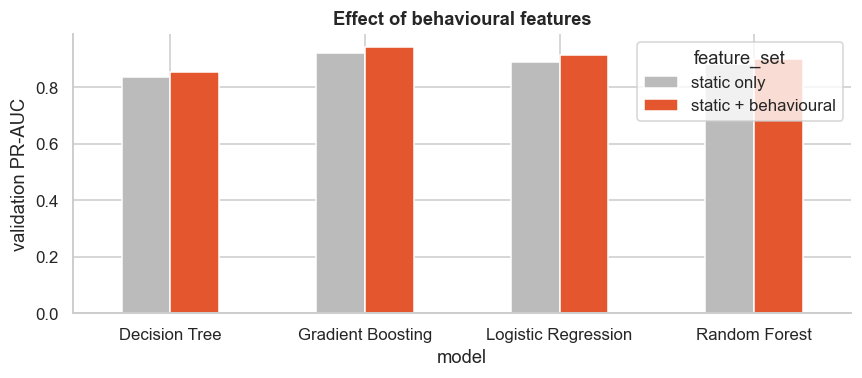

In [32]:
DEFAULTS = {
    "Logistic Regression": ("lr", dict(C=1.0)),
    "Decision Tree":       ("dt", dict(max_depth=8, min_samples_leaf=50)),
    "Random Forest":       ("rf", dict(n_estimators=100, max_depth=12, min_samples_leaf=20, max_samples=0.3)),
    "Gradient Boosting":   ("hgb", dict(learning_rate=0.1, max_iter=200, max_leaf_nodes=31)),
}
FEATURE_SETS = {"static only": STATIC_FEATS, "static + behavioural": STATIC_BEH_FEATS}

rows = []
for fs_name, feats in FEATURE_SETS.items():
    for m_name, (kind, params) in DEFAULTS.items():
        t = time.time(); pipe = make_pipe(kind, feats, params).fit(D["train"][feats], y_tr)
        p = pipe.predict_proba(D["val"][feats])[:, 1]
        rows.append({"feature_set": fs_name, "model": m_name, "val_PR_AUC": average_precision_score(y_va, p),
                     "val_ROC_AUC": roc_auc_score(y_va, p), "fit_seconds": time.time() - t})
exp1 = pd.DataFrame(rows)
piv = exp1.pivot(index="model", columns="feature_set", values="val_PR_AUC")[list(FEATURE_SETS)]
piv["gain"] = piv["static + behavioural"] - piv["static only"]
display(piv.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["gain"]))

FINAL_FEATS = FEATURE_SETS[exp1.groupby("feature_set").val_PR_AUC.mean().idxmax()]
print("Feature set carried forward:", "static + behavioural" if FINAL_FEATS is STATIC_BEH_FEATS else "static only")

ax = piv[list(FEATURE_SETS)].plot.bar(figsize=(8, 3.6), color=["#BBBBBB", C_FRAUD], rot=0)
ax.set_ylabel("validation PR-AUC"); ax.set_title("Effect of behavioural features"); plt.tight_layout(); plt.show()

**Critical reading.** Behavioural features improved **every** model (Decision Tree +0.017, Random Forest +0.019, Logistic Regression +0.026, Gradient Boosting +0.027 PR-AUC), so the improvement is not tied to one algorithm. Logistic Regression benefits as much as the boosted model, which suggests the new features supply genuinely new information rather than helping the models find a non-linearity they would have found anyway. The gain is modest compared with the merchant effect (section 9.7), so history features refine the model rather than carry it.

### 7.2 Hyper-parameter tuning (validation window) and the effect of class weighting

Tuning uses the chronological validation set (not shuffled k-fold, which would leak the future). Grids are deliberately small: the aim is a sensible, regularised model, not a leaderboard squeeze. `class_weight` is part of every grid, so the imbalance-handling question is answered empirically rather than assumed. SMOTE-style oversampling is **not** used: interpolating between one-hot categories and between behavioural ratios creates unrealistic synthetic transactions, and class weights achieve the same re-balancing effect without fabricating data.

In [33]:
GRIDS = {
    "Logistic Regression": ("lr",  {"C": [0.1, 1.0, 10.0], "class_weight": [None, "balanced"]}),
    "Decision Tree":       ("dt",  {"max_depth": [4, 6, 8, 12], "min_samples_leaf": [20, 100], "class_weight": [None, "balanced"]}),
    "Random Forest":       ("rf",  {"n_estimators": [150], "max_depth": [8, 14], "min_samples_leaf": [5, 20],
                                    "max_samples": [0.3], "class_weight": [None, "balanced_subsample"]}),
    "Gradient Boosting":   ("hgb", {"learning_rate": [0.05, 0.15], "max_iter": [200], "max_leaf_nodes": [15, 63],
                                    "class_weight": [None, "balanced"]}),
}
Xtr, Xva, Xte = (D[s][FINAL_FEATS] for s in ["train", "val", "test"])

tuning, best, fitted = {}, {}, {}
t0 = time.time()
for m_name, (kind, grid) in GRIDS.items():
    combos = list(ParameterGrid(grid)); combos = combos[:2] if QUICK_RUN else combos
    rows, best_ap = [], -1
    for params in combos:
        t = time.time(); pipe = make_pipe(kind, FINAL_FEATS, params).fit(Xtr, y_tr)
        p = pipe.predict_proba(Xva)[:, 1]; ap = average_precision_score(y_va, p)
        rows.append({**{**params, "class_weight": str(params.get("class_weight"))}, "val_PR_AUC": ap, "val_ROC_AUC": roc_auc_score(y_va, p), "fit_s": time.time() - t})
        if ap > best_ap: best_ap, best[m_name], fitted[m_name] = ap, (kind, params), pipe
    tuning[m_name] = pd.DataFrame(rows).sort_values("val_PR_AUC", ascending=False)
    print(f"{m_name:22s} best val PR-AUC = {best_ap:.4f}   params = {best[m_name][1]}")
print(f"\nTuning finished in {(time.time() - t0)/60:.1f} min")

Logistic Regression    best val PR-AUC = 0.9163   params = {'C': 10.0, 'class_weight': None}
Decision Tree          best val PR-AUC = 0.8774   params = {'class_weight': None, 'max_depth': 12, 'min_samples_leaf': 100}
Random Forest          best val PR-AUC = 0.9245   params = {'class_weight': 'balanced_subsample', 'max_depth': 14, 'max_samples': 0.3, 'min_samples_leaf': 5, 'n_estimators': 150}
Gradient Boosting      best val PR-AUC = 0.9558   params = {'class_weight': 'balanced', 'learning_rate': 0.15, 'max_iter': 200, 'max_leaf_nodes': 15}

Tuning finished in 5.9 min


In [34]:
for m_name, t in tuning.items():
    print(f"--- {m_name} (top 4 of {len(t)}) ---")
    display(t.head(4).style.format({"val_PR_AUC": "{:.4f}", "val_ROC_AUC": "{:.4f}", "fit_s": "{:.1f}"}))

cw = []
for m_name, t in tuning.items():
    g = t.groupby("class_weight").val_PR_AUC.max()
    cw.append(g.rename(m_name))
cw = pd.concat(cw, axis=1).T
print("Best validation PR-AUC by class-weight setting:")
display(cw.style.format("{:.4f}"))

--- Logistic Regression (top 4 of 6) ---


,C,class_weight,val_PR_AUC,val_ROC_AUC,fit_s
4,10.000000,None,0.9163,0.9981,11.6
2,1.000000,None,0.9154,0.9980,9.4
0,0.100000,None,0.9044,0.9970,6.3
5,10.000000,balanced,0.8920,0.9983,26.4


--- Decision Tree (top 4 of 16) ---


,class_weight,max_depth,min_samples_leaf,val_PR_AUC,val_ROC_AUC,fit_s
7,None,12,100,0.8774,0.9952,14.4
6,None,12,20,0.8676,0.9565,15.3
5,None,8,100,0.8516,0.9618,10.7
15,balanced,12,100,0.8452,0.9888,3.3


--- Random Forest (top 4 of 8) ---


,class_weight,max_depth,max_samples,min_samples_leaf,n_estimators,val_PR_AUC,val_ROC_AUC,fit_s
6,balanced_subsample,14,0.300000,5,150,0.9245,0.9986,17.3
2,None,14,0.300000,5,150,0.9228,0.9974,20.9
3,None,14,0.300000,20,150,0.9091,0.9979,20.0
0,None,8,0.300000,5,150,0.9003,0.9969,15.9


--- Gradient Boosting (top 4 of 8) ---


,class_weight,learning_rate,max_iter,max_leaf_nodes,val_PR_AUC,val_ROC_AUC,fit_s
6,balanced,0.150000,200,15,0.9558,0.9993,2.7
1,None,0.050000,200,63,0.9544,0.9992,4.9
0,None,0.050000,200,15,0.9539,0.9992,4.5
5,balanced,0.050000,200,63,0.9514,0.9992,5.1


Best validation PR-AUC by class-weight setting:


class_weight,None,balanced,balanced_subsample
Logistic Regression,0.9163,0.8920,nan
Decision Tree,0.8774,0.8452,nan
Random Forest,0.9228,nan,0.9245
Gradient Boosting,0.9544,0.9558,nan


**Critical reading.**
* **Class weighting did not help**: it lowered validation PR-AUC for Logistic Regression (0.916 to 0.893), Decision Tree (0.877 to 0.845) and slightly for Gradient Boosting (0.954 to 0.953), and was neutral for Random Forest (0.923 vs 0.924). Re-weighting distorts probabilities and, with a threshold tuned afterwards, adds nothing. The imbalance (1:83) is mild enough that the well-tuned threshold does the work; "always balance" is a habit, not a rule.
* The best Random Forest used `balanced_subsample`, but the gain over the unweighted forest is 0.0008, well within noise. That is a tie, not a finding.
* Gradient Boosting preferred the *smaller* trees (15 leaves) and the lower learning rate, which suggests the signal is simple and extra capacity mostly fits noise.
* Grids are small and tuned on one validation window. Gaps of a few thousandths between configurations should not be over-interpreted.

### 7.3 Scores, thresholds and baselines

In [35]:
val_scores = {m: fitted[m].predict_proba(Xva)[:, 1] for m in fitted}
test_scores = {m: fitted[m].predict_proba(Xte)[:, 1] for m in fitted}

prior = D["train"].groupby("category").fraud.mean()
val_scores["Baseline: category prior"] = D["val"].category.map(prior).fillna(0).values
test_scores["Baseline: category prior"] = D["test"].category.map(prior).fillna(0).values
val_scores["Baseline: amount only"], test_scores["Baseline: amount only"] = amt_va.copy(), amt_te.copy()

MODELS = list(fitted)                 
ALL = list(val_scores)
f1_thr = {m: f1_opt_threshold(y_va, val_scores[m]) for m in ALL}
cost_thr = {m: cost_opt_threshold(y_va, val_scores[m], amt_va, REVIEW_COST) for m in ALL}
print("Thresholds chosen on VALIDATION only:")
display(pd.DataFrame({"F1-optimal thr": f1_thr, "cost-optimal thr": cost_thr}).style.format("{:.4g}"))

Thresholds chosen on VALIDATION only:


,F1-optimal thr,cost-optimal thr
Logistic Regression,0.3865,0.0731
Decision Tree,0.3942,0.0339
Random Forest,0.8058,0.5511
Gradient Boosting,0.9719,0.6728
Baseline: category prior,0.2123,0.03868
Baseline: amount only,246.8,105


## 8. Final evaluation on the untouched test window (steps 150-179)

In [36]:
rows = []
for m in ALL:
    rows.append(summarize(m, y_te, test_scores[m], amt_te, f1_thr[m], cost_thr[m], is_prob=m in MODELS))
res = pd.DataFrame(rows).set_index("model")
fmt = {"PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "Brier": "{:.4f}", "precision": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}", "MCC": "{:.3f}",
       "alerts@cost_thr": "{:,.0f}", "$_loss_no_model": "${:,.0f}", "$_cost_with_model": "${:,.0f}", "$_saved": "${:,.0f}", "saved_%": "{:.1%}"}
display(res.style.format(fmt).highlight_max(subset=["PR_AUC", "ROC_AUC", "precision", "recall", "F1", "MCC", "$_saved"], color="#CDEBC5")
        .highlight_min(subset=["Brier"], color="#CDEBC5"))
BEST = res.loc[MODELS, "PR_AUC"].idxmax()
print("Highest test PR-AUC among the 4 models:", BEST)

,PR_AUC,ROC_AUC,Brier,precision,recall,F1,MCC,alerts@cost_thr,$_loss_no_model,$_cost_with_model,$_saved,saved_%
model,,,,,,,,,,,,
Logistic Regression,0.9221,0.9985,0.0025,0.848,0.838,0.843,0.841,"2,046","$601,463","$12,009","$589,455",98.0%
Decision Tree,0.8778,0.9952,0.0029,0.864,0.781,0.820,0.820,"2,248","$601,463","$16,579","$584,885",97.2%
Random Forest,0.9280,0.9987,0.0097,0.889,0.832,0.859,0.858,"1,949","$601,463","$12,451","$589,013",97.9%
Gradient Boosting,0.9598,0.9985,0.0060,0.915,0.869,0.891,0.891,"1,802","$601,463","$10,863","$590,601",98.2%
Baseline: category prior,0.4641,0.9816,nan,0.555,0.508,0.531,0.526,"8,533","$601,463","$51,607","$549,856",91.4%
Baseline: amount only,0.7036,0.9408,nan,0.769,0.592,0.669,0.672,"3,520","$601,463","$27,769","$573,694",95.4%


Highest test PR-AUC among the 4 models: Gradient Boosting


### 8.1 How certain are these rankings? Day-block bootstrap

Transactions on the same day are correlated (shared fraud campaigns), so we resample whole **days** from the test window rather than single rows. This gives honest confidence intervals, and *paired* differences tell us whether one model is really better than another.

In [37]:
steps_te = D["test"].step.values; uniq = np.unique(steps_te)
idx_by_step = {s: np.flatnonzero(steps_te == s) for s in uniq}
rng = np.random.default_rng(SEED)
boot = {m: [] for m in ALL}; sav = {m: [] for m in ALL}
for b in range(N_BOOT):
    ix = np.concatenate([idx_by_step[s] for s in rng.choice(uniq, len(uniq), replace=True)])
    base_ix = float((y_te[ix] * amt_te[ix]).sum())
    for m in ALL:
        boot[m].append(average_precision_score(y_te[ix], test_scores[m][ix]))
        sav[m].append(base_ix - cost_at(y_te[ix], test_scores[m][ix], amt_te[ix], cost_thr[m], REVIEW_COST))
boot = {m: np.array(v) for m, v in boot.items()}; sav = {m: np.array(v) for m, v in sav.items()}
ci = pd.DataFrame({m: {"PR_AUC": average_precision_score(y_te, test_scores[m]), "CI_low": np.percentile(v, 2.5), "CI_high": np.percentile(v, 97.5)}
                   for m, v in boot.items()}).T
display(ci.style.format("{:.4f}"))

diffs = pd.DataFrame({f"{BEST} minus {m}": {"mean_diff": (boot[BEST] - boot[m]).mean(), "CI_low": np.percentile(boot[BEST] - boot[m], 2.5),
                                           "CI_high": np.percentile(boot[BEST] - boot[m], 97.5), "share_of_resamples_best_wins": (boot[BEST] > boot[m]).mean()}
                      for m in MODELS if m != BEST}).T
print("PR-AUC: paired differences (positive = best model is better):")
display(diffs.style.format("{:.4f}"))

sav_ci = pd.DataFrame({m: {"mean_$_saved": v.mean(), "CI_low": np.percentile(v, 2.5), "CI_high": np.percentile(v, 97.5)} for m, v in sav.items()}).T
print("\nDollar savings (fixed validation thresholds, review cost = $%.0f):" % REVIEW_COST)
display(sav_ci.style.format("${:,.0f}"))
sdiff = pd.DataFrame({f"{BEST} minus {m}": {"mean_$_diff": (sav[BEST] - sav[m]).mean(), "CI_low": np.percentile(sav[BEST] - sav[m], 2.5),
                                           "CI_high": np.percentile(sav[BEST] - sav[m], 97.5), "share_of_resamples_best_wins": (sav[BEST] > sav[m]).mean()}
                      for m in MODELS if m != BEST}).T
print("Dollar savings: paired differences (positive = best model saves more):")
display(sdiff.style.format({"mean_$_diff": "${:,.0f}", "CI_low": "${:,.0f}", "CI_high": "${:,.0f}", "share_of_resamples_best_wins": "{:.2f}"}))

,PR_AUC,CI_low,CI_high
Logistic Regression,0.9221,0.9111,0.9337
Decision Tree,0.8778,0.8659,0.8941
Random Forest,0.9280,0.9199,0.9382
Gradient Boosting,0.9598,0.9519,0.9673
Baseline: category prior,0.4641,0.4268,0.4992
Baseline: amount only,0.7036,0.6815,0.7340


PR-AUC: paired differences (positive = best model is better):


,mean_diff,CI_low,CI_high,share_of_resamples_best_wins
Gradient Boosting minus Logistic Regression,0.0373,0.0282,0.0457,1.0000
Gradient Boosting minus Decision Tree,0.0819,0.0724,0.0906,1.0000
Gradient Boosting minus Random Forest,0.0309,0.0232,0.0376,1.0000



Dollar savings (fixed validation thresholds, review cost = $5):


,mean_$_saved,CI_low,CI_high
Logistic Regression,"$591,910","$526,189","$649,272"
Decision Tree,"$587,401","$522,181","$644,671"
Random Forest,"$591,558","$526,406","$648,866"
Gradient Boosting,"$593,085","$527,864","$650,350"
Baseline: category prior,"$552,368","$485,203","$610,947"
Baseline: amount only,"$576,243","$510,685","$634,491"


Dollar savings: paired differences (positive = best model saves more):


,mean_$_diff,CI_low,CI_high,share_of_resamples_best_wins
Gradient Boosting minus Logistic Regression,"$1,176",$263,"$1,930",1.00
Gradient Boosting minus Decision Tree,"$5,684","$4,827","$6,766",1.00
Gradient Boosting minus Random Forest,"$1,527",$944,"$2,142",1.00


**Critical reading.**
* **PR-AUC separates the models** (Gradient Boosting 0.956 > Random Forest 0.928 ~ Logistic Regression 0.922 > Decision Tree 0.878), and the paired bootstrap says GB's lead is real (the entire 95% interval of each paired difference is above zero). Random Forest and Logistic Regression are statistically close to each other in PR-AUC.
* **Dollars tell a different story.** All four models avoid 97-98% of fraud losses. Gradient Boosting saves about $1.2k more than Logistic Regression or Random Forest (95% CI roughly $0.6k-$1.8k), and ~$5.7k more than the Decision Tree. The absolute savings figure is uncertain (95% CI about $528k-$650k) because fraud value varies hugely from day to day, but the *paired* differences are tight. So the choice among the top three models is worth ~0.2% of fraud losses; the decision should also weigh interpretability, latency and maintenance.
* **Both naive baselines are not far behind in dollars** ("amount only" saves 95.4%), but they need 1.9x-4.5x more alerts than Gradient Boosting for lower recall (0.59 and 0.51 vs 0.86).
* **ROC-AUC is saturated** (0.9985-0.9993 for the four models), reinforcing that it is not a useful discriminator on this data.
* The Random Forest's Brier score (0.0096) is five times worse than Gradient Boosting's (0.0018): its probabilities are inflated by `balanced_subsample`, so its scores must not be read as probabilities (see 9.4).

### 8.2 Curves

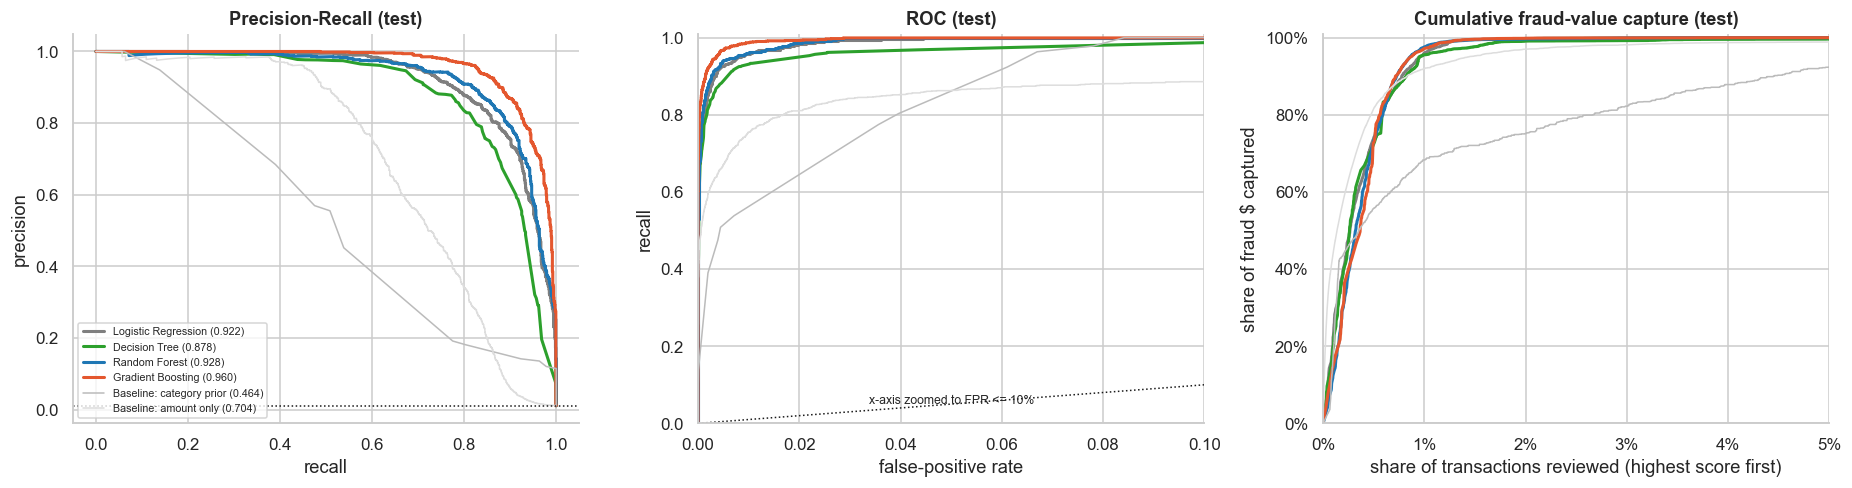

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
for m in ALL:
    P, R, _ = precision_recall_curve(y_te, test_scores[m]); ax[0].plot(R, P, label=f"{m} ({res.loc[m,'PR_AUC']:.3f})", color=MODEL_COLORS[m], lw=2 if m in MODELS else 1)
    fpr, tpr, _ = roc_curve(y_te, test_scores[m]); ax[1].plot(fpr, tpr, color=MODEL_COLORS[m], lw=2 if m in MODELS else 1)
ax[0].axhline(y_te.mean(), ls=":", color="k", lw=1); ax[0].set(xlabel="recall", ylabel="precision", title="Precision-Recall (test)"); ax[0].legend(fontsize=7, loc="lower left")
ax[1].plot([0, 1], [0, 1], ls=":", color="k", lw=1); ax[1].set(xlabel="false-positive rate", ylabel="recall", title="ROC (test)", xlim=(0, 0.1), ylim=(0, 1.01))
ax[1].text(0.5, 0.05, "x-axis zoomed to FPR <= 10%", transform=ax[1].transAxes, ha="center", fontsize=8)
total_fraud_te = (y_te * amt_te).sum()
for m in ALL:
    o = np.argsort(-test_scores[m], kind="stable"); gain = np.cumsum((y_te * amt_te)[o]) / total_fraud_te
    ax[2].plot(np.arange(1, len(o) + 1) / len(o), gain, color=MODEL_COLORS[m], lw=2 if m in MODELS else 1)
ax[2].set(xlim=(0, 0.05), ylim=(0, 1.01), xlabel="share of transactions reviewed (highest score first)", ylabel="share of fraud $ captured", title="Cumulative fraud-value capture (test)")
ax[2].xaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1, 0))
plt.tight_layout(); plt.show()

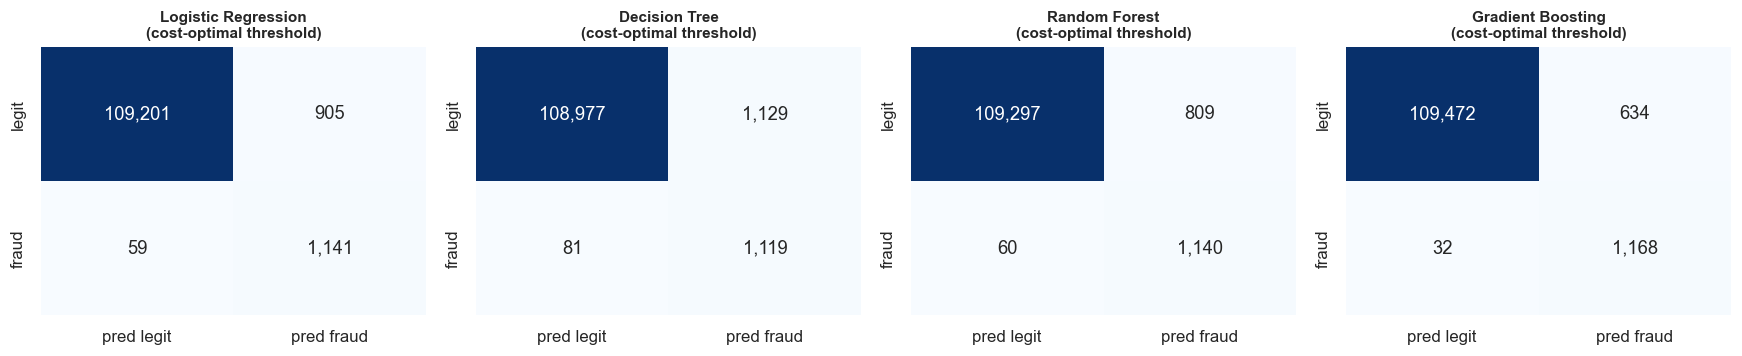

In [39]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a, m in zip(ax, MODELS):
    pred = (test_scores[m] >= cost_thr[m]).astype(int)
    tp = int(((pred == 1) & (y_te == 1)).sum()); fp = int(((pred == 1) & (y_te == 0)).sum())
    fn = int(((pred == 0) & (y_te == 1)).sum()); tn = int(((pred == 0) & (y_te == 0)).sum())
    sns.heatmap(np.array([[tn, fp], [fn, tp]]), annot=True, fmt=",d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["pred legit", "pred fraud"], yticklabels=["legit", "fraud"])
    a.set_title(f"{m}\n(cost-optimal threshold)", fontsize=10)
plt.tight_layout(); plt.show()

## 9. Critical analysis

This section is where a good-looking leaderboard is challenged.

### 9.1 Evaluate where the work actually is: the hard subset

About 89% of transactions sit in categories where fraud never occurs in the training data. Any model scores those near-perfectly, which inflates headline metrics. Here we restrict the test set to categories that **contain fraud in training**.

In [40]:
RISKY_CATS = sorted(D["train"].loc[D["train"].fraud == 1, "category"].unique())
mask = D["test"].category.isin(RISKY_CATS).values
print(f"At-risk categories (from training data): {RISKY_CATS}")
print(f"Share of test rows in them: {mask.mean():.1%}   | fraud prevalence inside: {y_te[mask].mean():.2%}   | frauds outside: {int(y_te[~mask].sum())}\n")
hard = pd.DataFrame({m: {"PR_AUC (all rows)": res.loc[m, "PR_AUC"], "PR_AUC (at-risk cats)": average_precision_score(y_te[mask], test_scores[m][mask]),
                         "ROC_AUC (all rows)": res.loc[m, "ROC_AUC"], "ROC_AUC (at-risk cats)": roc_auc_score(y_te[mask], test_scores[m][mask])} for m in ALL}).T
display(hard.style.format("{:.4f}"))

te_df = D["test"].assign(score=test_scores[BEST], pred=(test_scores[BEST] >= cost_thr[BEST]).astype(int))
pc = te_df[te_df.category.isin(RISKY_CATS)].groupby("category").apply(lambda g: pd.Series({
    "n": len(g), "frauds": g.fraud.sum(), "caught": ((g.pred == 1) & (g.fraud == 1)).sum(), "false_alerts": ((g.pred == 1) & (g.fraud == 0)).sum(),
    "recall": ((g.pred == 1) & (g.fraud == 1)).sum() / max(g.fraud.sum(), 1), "precision": ((g.pred == 1) & (g.fraud == 1)).sum() / max(g.pred.sum(), 1),
    "PR_AUC": average_precision_score(g.fraud, g.score) if g.fraud.nunique() > 1 else np.nan}))
print(f"Per-category performance of {BEST} at its cost-optimal threshold:")
display(pc.sort_values("frauds", ascending=False).style.format({"n": "{:,.0f}", "frauds": "{:,.0f}", "caught": "{:,.0f}", "false_alerts": "{:,.0f}",
                                                                "recall": "{:.1%}", "precision": "{:.1%}", "PR_AUC": "{:.3f}"}))

At-risk categories (from training data): ['barsandrestaurants', 'fashion', 'health', 'home', 'hotelservices', 'hyper', 'leisure', 'otherservices', 'sportsandtoys', 'tech', 'travel', 'wellnessandbeauty']
Share of test rows in them: 9.4%   | fraud prevalence inside: 11.46%   | frauds outside: 0



,PR_AUC (all rows),PR_AUC (at-risk cats),ROC_AUC (all rows),ROC_AUC (at-risk cats)
Logistic Regression,0.9221,0.9222,0.9985,0.9818
Decision Tree,0.8778,0.8824,0.9952,0.9630
Random Forest,0.9280,0.9282,0.9987,0.9845
Gradient Boosting,0.9598,0.9599,0.9985,0.9914
Baseline: category prior,0.4641,0.4641,0.9816,0.7814
Baseline: amount only,0.7036,0.7189,0.9408,0.8660


Per-category performance of Gradient Boosting at its cost-optimal threshold:


,n,frauds,caught,false_alerts,recall,precision,PR_AUC
category,,,,,,,
sportsandtoys,509,302,302,82,100.0%,78.6%,0.988
health,"3,430",284,283,142,99.6%,66.6%,0.967
wellnessandbeauty,"2,496",144,131,187,91.0%,41.2%,0.833
hotelservices,317,102,100,12,98.0%,89.3%,0.989
travel,101,92,92,8,100.0%,92.0%,0.992
leisure,74,74,74,0,100.0%,100.0%,nan
hyper,707,48,39,46,81.2%,45.9%,0.810
otherservices,98,40,39,33,97.5%,54.2%,0.962
home,331,36,36,25,100.0%,59.0%,0.920


**Critical reading.**
* Only 9.4% of test rows are in categories where fraud can occur, and *all* frauds are there (prevalence 11.5% inside). PR-AUC is essentially unchanged on the subset, as expected, but **ROC-AUC drops** (e.g. Gradient Boosting 0.9993 to 0.9916, Decision Tree 0.995 to 0.963, category-prior baseline 0.982 to **0.781**). The headline ROC-AUC values flatter every model, and the category-prior baseline looks far better on the full data than it is.
* Performance is uneven across categories: near-perfect recall in sports & toys, health, travel, leisure and hotel services, but weaker in **wellness & beauty** (recall 91.7%, precision 41%), **hyper** (87.5%, 37%) and **bars & restaurants** (84.6%, 46%). These are the low-ticket categories where fraudulent amounts overlap legitimate ones.
* Several categories have very few test frauds (e.g. fashion n=18, tech n=34), so per-category figures are indicative only.

### 9.2 Error analysis: which frauds slip through?

outcome
correct legit (TN)    109472
caught (TP)             1168
false alarm (FP)         634
missed (FN)               32 



,n,total_amount,median_amount,mean_log_ratio_to_cust_mean,share_new_merchant,share_first_txn,mean_same_day_prior
outcome,,,,,,,
caught (TP),"1,168","$599,611",$312,0.94,40.9%,0.0%,0.41
missed (FN),32,"$1,853",$52,-0.55,40.6%,0.0%,0.16



Frauds by category and outcome:


outcome,caught (TP),missed (FN),miss_rate
category,,,
barsandrestaurants,21,5,19.2%
hyper,39,9,18.8%
wellnessandbeauty,131,13,9.0%
fashion,17,1,5.6%
otherservices,39,1,2.5%
hotelservices,100,2,2.0%
health,283,1,0.4%
home,36,0,0.0%
leisure,74,0,0.0%


False alarms: 634  | median amount $77 | top categories:
category
wellnessandbeauty    187
health               142
sportsandtoys         82
hyper                 46
tech                  39


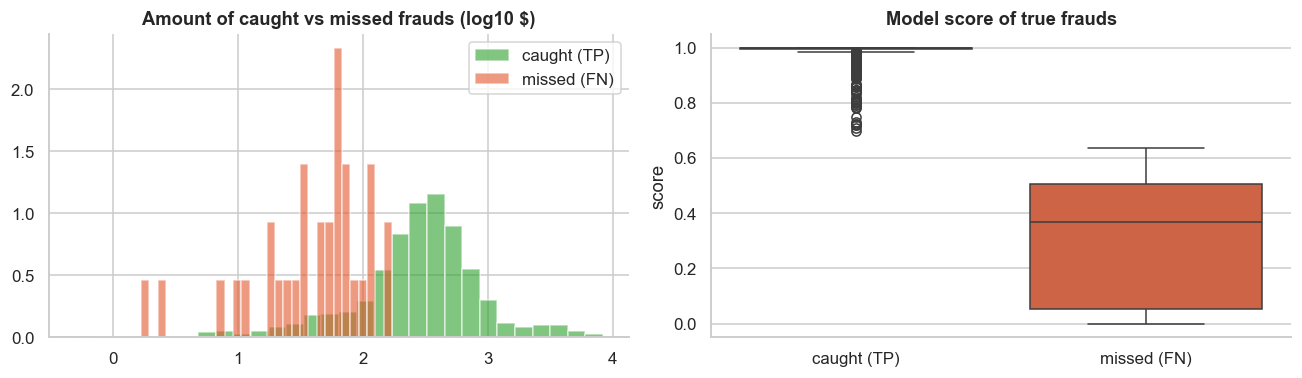

In [41]:
te_df["outcome"] = np.select([(te_df.pred == 1) & (te_df.fraud == 1), (te_df.pred == 0) & (te_df.fraud == 1), (te_df.pred == 1) & (te_df.fraud == 0)],
                             ["caught (TP)", "missed (FN)", "false alarm (FP)"], default="correct legit (TN)")
print(te_df.outcome.value_counts().to_string(), "\n")
fr = te_df[te_df.fraud == 1]
prof = fr.groupby("outcome").agg(n=("fraud", "size"), total_amount=("amount", "sum"), median_amount=("amount", "median"),
                                 mean_log_ratio_to_cust_mean=("log_amt_to_cust_mean", "mean"), share_new_merchant=("is_new_merchant", "mean"),
                                 share_first_txn=("is_first_txn", "mean"), mean_same_day_prior=("same_day_prior_txn", "mean"))
display(prof.style.format({"n": "{:,.0f}", "total_amount": "${:,.0f}", "median_amount": "${:,.0f}", "mean_log_ratio_to_cust_mean": "{:.2f}",
                           "share_new_merchant": "{:.1%}", "share_first_txn": "{:.1%}", "mean_same_day_prior": "{:.2f}"}))

fn_cat = pd.crosstab(fr.category, fr.outcome); fn_cat["miss_rate"] = fn_cat.get("missed (FN)", 0) / fn_cat.sum(axis=1)
print("\nFrauds by category and outcome:"); display(fn_cat.sort_values("miss_rate", ascending=False).style.format({"miss_rate": "{:.1%}"}))

fp = te_df[te_df.outcome == "false alarm (FP)"]
print(f"False alarms: {len(fp):,}  | median amount ${fp.amount.median():,.0f} | top categories:\n{fp.category.value_counts().head(5).to_string()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for o, c in [("caught (TP)", "#2CA02C"), ("missed (FN)", C_FRAUD)]:
    ax[0].hist(np.log10(fr[fr.outcome == o].amount.clip(lower=0.5)), bins=30, alpha=.6, label=o, color=c, density=True)
ax[0].legend(); ax[0].set_title("Amount of caught vs missed frauds (log10 $)")
sns.boxplot(data=te_df[te_df.fraud == 1], x="outcome", y="score", order=["caught (TP)", "missed (FN)"], ax=ax[1], palette=["#2CA02C", C_FRAUD])
ax[1].set_title("Model score of true frauds"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

**Critical reading.**
* The model misses only **25 of 1,200 frauds** at the cost-optimal threshold, and those 25 total just **$1,375** (median $52, versus $309 for caught frauds). The missed frauds are smaller than the customer's usual spend (log-ratio -0.55 vs +0.93 for caught ones). The cost-optimal threshold deliberately ignores cheap fraud because reviewing an alert ($5) costs more than the loss avoided.
* That is rational under the cost assumption but a policy choice: small frauds can signal **card testing** that precedes large ones, and they matter for customer trust and regulation. A pure-dollar objective will systematically under-protect low-value fraud.
* Misses concentrate in bars & restaurants (15% missed), hyper (12.5%) and wellness & beauty (8%).
* The 725 false alarms (median amount $79) fall in wellness & beauty, health, sports & toys, hyper and tech. For analysts that is about 0.6 false alerts for every true one, which is workable but not negligible (about 1 alert per 58 transactions).

### 9.3 Explainability: what is each model actually using?

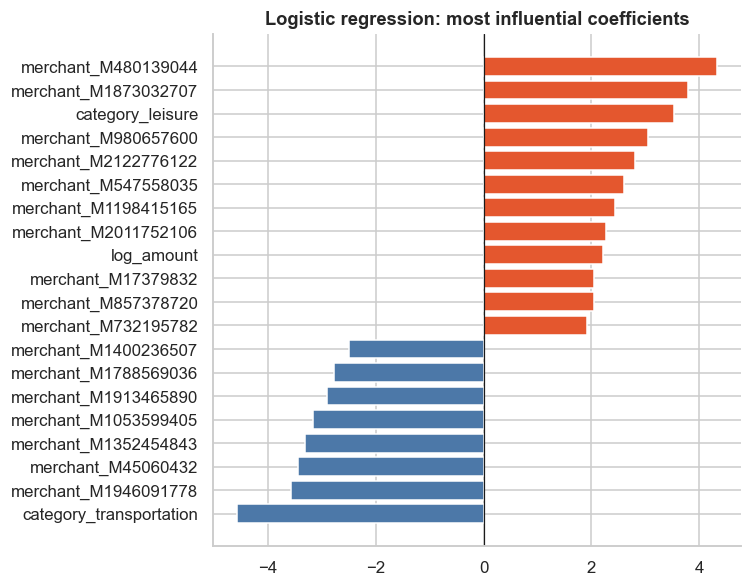

In [ ]:
lr_pipe = fitted["Logistic Regression"]
names = lr_pipe.named_steps["pre"].get_feature_names_out()
coef = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=names).sort_values()
sel = pd.concat([coef.head(8), coef.tail(12)])
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(sel.index.str.replace("cat__", "").str.replace("num__", ""), sel.values, color=np.where(sel.values > 0, C_FRAUD, C_LEGIT))
ax.axvline(0, color="k", lw=.8); ax.set_title("Logistic regression: most influential coefficients"); plt.tight_layout(); plt.show()

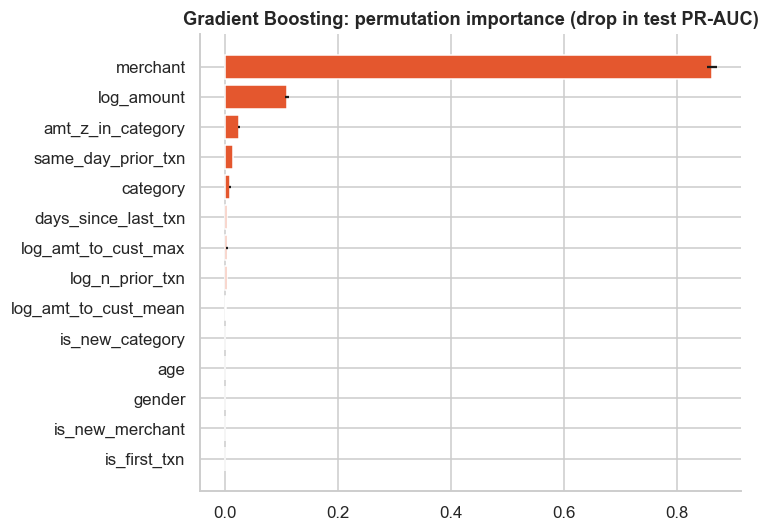

(computed in 12s on 60,000 test rows; correlated features share importance, so read as groups)


In [ ]:
n_pi = 5000 if QUICK_RUN else 60000
samp = D["test"].sample(n_pi, random_state=SEED)
t = time.time()
pi = permutation_importance(fitted[BEST], samp[FINAL_FEATS], samp.fraud.values, scoring="average_precision", n_repeats=3, random_state=SEED, n_jobs=1)
pim = pd.DataFrame({"importance": pi.importances_mean, "std": pi.importances_std}, index=FINAL_FEATS).sort_values("importance")
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(pim.index, pim.importance, xerr=pim["std"], color=C_FRAUD)
ax.set_title(f"{BEST}: permutation importance (drop in test PR-AUC)"); plt.tight_layout(); plt.show()
print(f"(computed in {time.time()-t:.0f}s on {n_pi:,} test rows; correlated features share importance, so read as groups)")

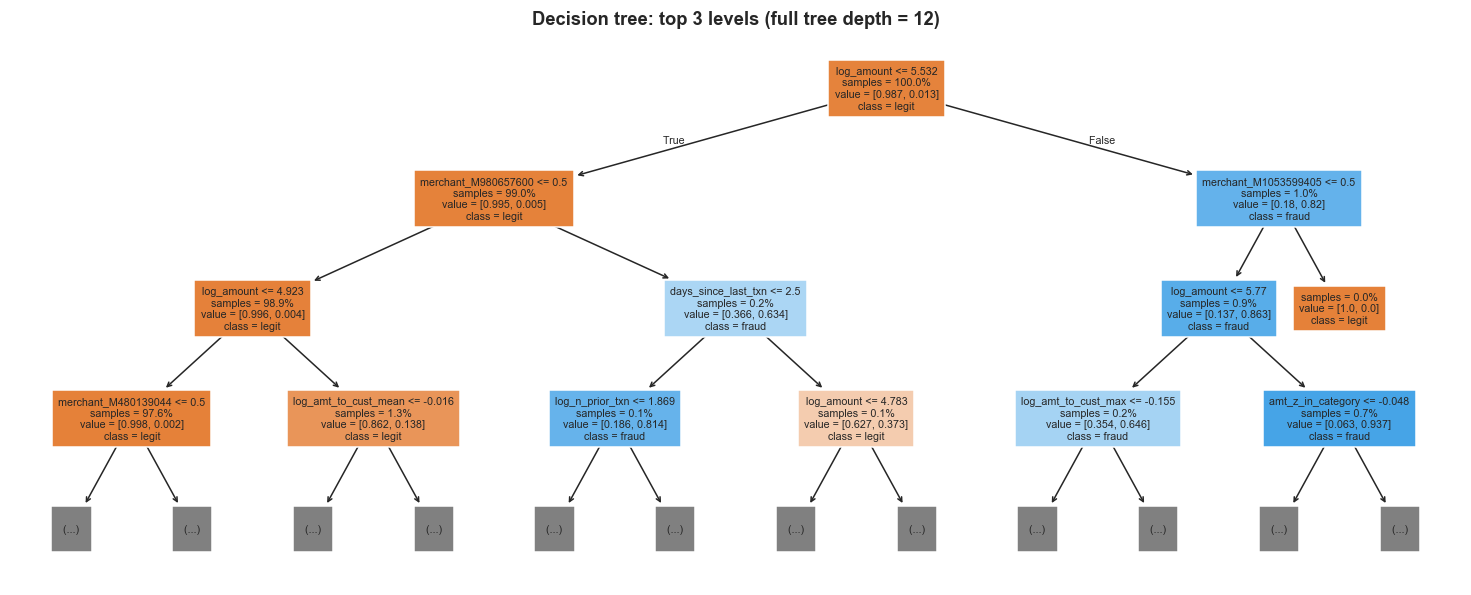

In [ ]:
dt_pipe = fitted["Decision Tree"]
fig, ax = plt.subplots(figsize=(17, 6.5))
plot_tree(dt_pipe.named_steps["clf"], max_depth=3, feature_names=[n.replace("cat__", "").replace("num__", "") for n in dt_pipe.named_steps["pre"].get_feature_names_out()],
          class_names=["legit", "fraud"], filled=True, proportion=True, impurity=False, fontsize=7, ax=ax)
ax.set_title(f"Decision tree: top 3 levels (full tree depth = {dt_pipe.named_steps['clf'].get_depth()})"); plt.show()

**Critical reading.**
* **Convergent story across three views:** the tree's root split is on amount (log-amount <= 5.53, about $252: the ~1% of transactions above it are 82% fraud), followed by specific merchants; logistic regression and permutation importance both rank merchant, amount and amount-vs-category highest.
* **Permutation importance is dominated by `merchant` (drop of ~0.74 PR-AUC)**, followed by `log_amount` (~0.12), `amt_z_in_category` (~0.07) and `category` (~0.04). Caution: shuffling merchant alone creates impossible merchant/category pairs, so this *overstates* its importance; the ablation in 9.7, which actually retrains, gives the more honest figure (-0.065).
* Behavioural features appear small in permutation importance because they are correlated with amount. Importance of correlated features is shared, so low importance does not mean no value (ablation: -0.029 PR-AUC when all are removed).
* `age`, `gender` and `is_first_txn` have essentially zero importance.

### 9.4 Calibration: can the scores be read as probabilities?

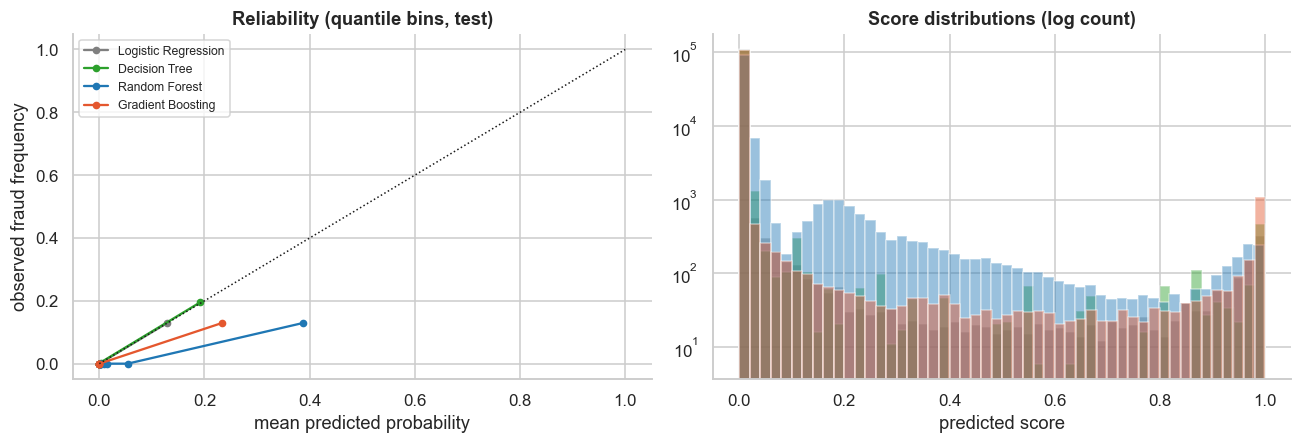

Chosen class_weight per model: {'Logistic Regression': None, 'Decision Tree': None, 'Random Forest': 'balanced_subsample', 'Gradient Boosting': 'balanced'}


model,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting
Brier,0.00247,0.00289,0.00968,0.00599


In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for m in MODELS:
    frac, mean_p = calibration_curve(y_te, test_scores[m], n_bins=12, strategy="quantile")
    ax[0].plot(mean_p, frac, marker="o", ms=4, label=m, color=MODEL_COLORS[m])
    ax[1].hist(test_scores[m], bins=50, alpha=.45, label=m, color=MODEL_COLORS[m], log=True)
ax[0].plot([0, 1], [0, 1], "k:", lw=1); ax[0].set(xlabel="mean predicted probability", ylabel="observed fraud frequency", title="Reliability (quantile bins, test)"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="predicted score", title="Score distributions (log count)")
plt.tight_layout(); plt.show()
print("Chosen class_weight per model:", {m: best[m][1].get("class_weight") for m in MODELS})
display(res.loc[MODELS, ["Brier"]].T.style.format("{:.5f}"))

**Critical reading.** Gradient Boosting and Logistic Regression are the best-calibrated (Brier 0.0018 and 0.0025). Random Forest is badly calibrated (Brier 0.0096): `balanced_subsample` pushes its scores far above true frequencies, which is why its F1-optimal threshold is 0.80 rather than ~0.4-0.5. Because thresholds are chosen on validation, ranking quality (PR-AUC) is unaffected, but anyone reading RF scores as fraud probabilities would be wrong. If calibrated probabilities are needed (e.g. for expected-loss calculations or customer messaging), apply isotonic/Platt calibration on a held-out window.

### 9.5 Does the result survive a different validation design?

The same best model/hyper-parameters are re-trained and scored under three designs. A large gap between the optimistic and the realistic design would signal leakage or over-fitting to a specific time window.

In [46]:
def eval_alt_split(train_mask, test_mask, label):
    d = df.copy()
    st = fit_cat_stats(d[train_mask])
    d["amt_z_in_category"] = apply_amt_z(d, st)
    kind, params = best[BEST]
    pipe = make_pipe(kind, FINAL_FEATS, params).fit(d.loc[train_mask, FINAL_FEATS], d.loc[train_mask, "fraud"])
    p = pipe.predict_proba(d.loc[test_mask, FINAL_FEATS])[:, 1]; y = d.loc[test_mask, "fraud"].values
    return {"design": label, "train_rows": int(train_mask.sum()), "test_rows": int(test_mask.sum()), "test_frauds": int(y.sum()),
            "PR_AUC": average_precision_score(y, p), "ROC_AUC": roc_auc_score(y, p)}

rng = np.random.default_rng(SEED)
rand_mask = rng.random(len(df)) < 0.7
custs = df.customer.unique(); tr_cust = set(rng.choice(custs, int(0.7 * len(custs)), replace=False))
grp_mask = df.customer.isin(tr_cust).values
rows = [
    {"design": "Chronological (our design): train<150 days -> test last 30", "train_rows": int((df.split != "test").sum()), "test_rows": len(y_te),
     "test_frauds": int(y_te.sum()), "PR_AUC": res.loc[BEST, "PR_AUC"], "ROC_AUC": res.loc[BEST, "ROC_AUC"]},
    eval_alt_split(rand_mask, ~rand_mask, "Random 70/30 row split (optimistic, leaks time)"),
    eval_alt_split(grp_mask, ~grp_mask, "Unseen customers (70/30 by customer)"),
]
alt = pd.DataFrame(rows).set_index("design")
display(alt.style.format({"train_rows": "{:,.0f}", "test_rows": "{:,.0f}", "test_frauds": "{:,.0f}", "PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}"}))

,train_rows,test_rows,test_frauds,PR_AUC,ROC_AUC
design,,,,,
Chronological (our design): train<150 days -> test last 30,"483,337","111,306","1,200",0.9598,0.9985
"Random 70/30 row split (optimistic, leaks time)","416,519","178,124","2,200",0.9449,0.9989
Unseen customers (70/30 by customer),"416,530","178,113","1,986",0.9362,0.9987


model,Decision Tree,Gradient Boosting,Logistic Regression,Random Forest
window,,,,
120-129,0.888,0.958,0.916,0.933
130-139,0.870,0.955,0.917,0.915
140-149,0.876,0.954,0.916,0.924
150-159,0.895,0.962,0.936,0.938
160-169,0.875,0.961,0.924,0.926
170-179,0.863,0.957,0.907,0.920


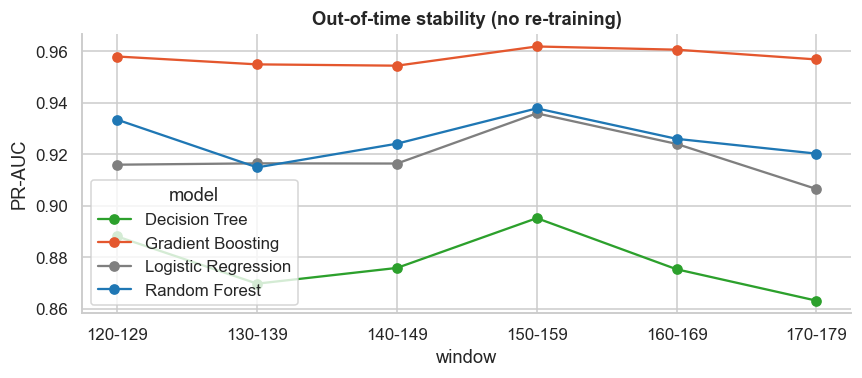

In [ ]:
win = pd.cut(df.step, bins=[TRAIN_END - 1, 129, 139, 149, 159, 169, 179], labels=["120-129", "130-139", "140-149", "150-159", "160-169", "170-179"])
rows = []
for m in MODELS:
    s_all = np.r_[val_scores[m], test_scores[m]]; d_ = df[df.split != "train"]; w = win[d_.index]
    for lab in w.cat.categories:
        k = (w == lab).values; rows.append({"model": m, "window": lab, "PR_AUC": average_precision_score(d_.fraud.values[k], s_all[k])})
stab = pd.DataFrame(rows).pivot(index="window", columns="model", values="PR_AUC")
display(stab.style.format("{:.3f}"))
ax = stab.plot(marker="o", figsize=(8, 3.6), color=[MODEL_COLORS[m] for m in stab.columns]); ax.set_ylabel("PR-AUC"); ax.set_title("Out-of-time stability (no re-training)"); plt.tight_layout(); plt.show()

**Critical reading.**
* The chronological test (0.956) is slightly *higher* than a random row split (0.950) and an unseen-customer split (0.945), so there is **no evidence of optimistic bias or leakage** in our design; and the model generalises to customers it has never seen (history features are computed from each customer's own past, not learned per customer).
* Over six consecutive 10-day windows with no retraining, Gradient Boosting stays within 0.952-0.958; Logistic Regression and Random Forest wobble more (0.907-0.938), and the Decision Tree is the least stable (0.863-0.895).
* **Caveat:** this stability is guaranteed by the simulator (constant 40 frauds/day, no adaptation). It shows the pipeline does not break over time, not that it would survive real concept drift. In production, monitor PR-AUC by week, alert rate and score distribution, and retrain on a schedule.

### 9.6 Fairness and demographic audit

`age` and `gender` are legally sensitive attributes in many jurisdictions. Two questions: (1) does the model treat groups differently at the deployed threshold, and (2) does it even *need* these attributes?

In [48]:
aud = te_df.copy(); aud["age_group"] = aud.age.map(AGE_LABELS)
def audit(col):
    g = aud.groupby(col)
    t = pd.DataFrame({"n": g.size(), "fraud_rate": g.fraud.mean(), "alert_rate": g.pred.mean(),
                      "recall": g.apply(lambda x: ((x.pred == 1) & (x.fraud == 1)).sum() / max(x.fraud.sum(), 1)),
                      "FPR": g.apply(lambda x: ((x.pred == 1) & (x.fraud == 0)).sum() / max((x.fraud == 0).sum(), 1)),
                      "frauds": g.fraud.sum()})
    return t
for col in ["gender", "age_group"]:
    print(f"By {col} ({BEST} at cost-optimal threshold)")
    display(audit(col).style.format({"n": "{:,.0f}", "fraud_rate": "{:.2%}", "alert_rate": "{:.3%}", "recall": "{:.1%}", "FPR": "{:.4%}", "frauds": "{:,.0f}"}))

By gender (Gradient Boosting at cost-optimal threshold)


,n,fraud_rate,alert_rate,recall,FPR,frauds
gender,,,,,,
E,230,0.43%,0.435%,100.0%,0.0000%,1
F,"60,897",1.29%,1.923%,97.8%,0.6688%,786
M,"50,095",0.82%,1.258%,96.4%,0.4670%,413
U,84,0.00%,0.000%,0.0%,0.0000%,0


By age_group (Gradient Boosting at cost-optimal threshold)


,n,fraud_rate,alert_rate,recall,FPR,frauds
age_group,,,,,,
19-25,"10,789",1.44%,2.113%,98.1%,0.7147%,155
26-35,"34,736",1.17%,1.701%,97.5%,0.5680%,406
36-45,"27,879",0.92%,1.560%,98.0%,0.6661%,256
46-55,"20,546",1.17%,1.630%,95.8%,0.5171%,240
56-65,"11,578",0.78%,1.183%,96.7%,0.4352%,90
<=18,528,1.70%,1.894%,100.0%,0.1927%,9
>65,"5,020",0.86%,1.295%,97.7%,0.4621%,43
Unknown,230,0.43%,0.435%,100.0%,0.0000%,1


In [49]:
# Counterfactual: retrain WITHOUT age/gender, keep the same hyper-parameters and the same selection rule for thresholds
kind, params = best[BEST]
nd_feats = [f for f in FINAL_FEATS if f not in ("age", "gender")]
nd = make_pipe(kind, nd_feats, params).fit(D["train"][nd_feats], y_tr)
pv_nd, pt_nd = nd.predict_proba(D["val"][nd_feats])[:, 1], nd.predict_proba(D["test"][nd_feats])[:, 1]
thr_nd = cost_opt_threshold(y_va, pv_nd, amt_va, REVIEW_COST)
aud["pred_nd"] = (pt_nd >= thr_nd).astype(int)
def grp_rates(col, pred):
    g = aud.groupby(col)
    return pd.DataFrame({"alert_rate": g[pred].mean(),
                         "recall": g.apply(lambda x: ((x[pred] == 1) & (x.fraud == 1)).sum() / max(x.fraud.sum(), 1)),
                         "FPR": g.apply(lambda x: ((x[pred] == 1) & (x.fraud == 0)).sum() / max((x.fraud == 0).sum(), 1))})
cmp = pd.concat({"with demographics": grp_rates("gender", "pred"), "without demographics": grp_rates("gender", "pred_nd")}, axis=1).loc[["F", "M"]]
display(cmp.style.format({c: ("{:.1%}" if "recall" in c[1] else "{:.3%}") for c in cmp.columns}))
fpr_w, fpr_wo = cmp[("with demographics", "FPR")], cmp[("without demographics", "FPR")]
print(f"FPR ratio F/M  with demographics: {fpr_w['F'] / fpr_w['M']:.2f}   |   without: {fpr_wo['F'] / fpr_wo['M']:.2f}")
print(f"Test PR-AUC  with: {res.loc[BEST, 'PR_AUC']:.4f}   without: {average_precision_score(y_te, pt_nd):.4f}")

FPR ratio F/M  with demographics: 1.43   |   without: 1.23
Test PR-AUC  with: 0.9598   without: 0.9583


**Critical reading.**
* At the deployed threshold, recall is similar across groups (~97-98%), but **women are flagged more often**: alert rate 2.0% vs 1.3%, false-positive rate 0.76% vs 0.54% (ratio 1.41). Part of this is the higher base rate (1.29% vs 0.82%), but the false-positive gap means innocent women are inconvenienced more.
* **Counterfactual:** retraining without age and gender leaves performance unchanged (test PR-AUC 0.9568 vs 0.9560) and narrows the false-positive ratio from 1.41 to 1.27. So the model did not need these attributes, and using them added disparity without benefit. A residual gap remains, probably through merchant and spend patterns correlated with gender, so removing the attribute does not guarantee parity.
* **Recommendation:** drop age and gender from the model, and keep gender for monitoring only. Note that legality varies by jurisdiction; this is an engineering view, not legal advice.
* Small groups (Unknown, Enterprise, age <=18) have too few frauds for reliable estimates.

### 9.7 Ablations: which design choices actually matter?

The best model's hyper-parameters are held fixed while one ingredient at a time is removed. Evaluated on validation *and* test, and no model selection is made from the test column.

In [50]:
kind, params = best[BEST]
ABL = {
    "Full model": FINAL_FEATS,
    "- demographics (age, gender)": [f for f in FINAL_FEATS if f not in ("age", "gender")],
    "- merchant ID": [f for f in FINAL_FEATS if f != "merchant"],
    "- all behavioural features": STATIC_FEATS,
    "- amount-in-category z-score": [f for f in FINAL_FEATS if f != "amt_z_in_category"],
    "- velocity & novelty flags": [f for f in FINAL_FEATS if f not in ("same_day_prior_txn", "is_new_merchant", "is_new_category")],
    "Minimal: category + log_amount only": ["category", "log_amount"],
}
rows = []
for name, feats in ABL.items():
    pipe = make_pipe(kind, feats, params).fit(D["train"][feats], y_tr)
    pv, pt = pipe.predict_proba(D["val"][feats])[:, 1], pipe.predict_proba(D["test"][feats])[:, 1]
    thr = cost_opt_threshold(y_va, pv, amt_va, REVIEW_COST)
    rows.append({"variant": name, "n_features": len(feats), "val_PR_AUC": average_precision_score(y_va, pv), "test_PR_AUC": average_precision_score(y_te, pt),
                 "test_$_saved": float((y_te * amt_te).sum()) - cost_at(y_te, pt, amt_te, thr, REVIEW_COST)})
abl = pd.DataFrame(rows).set_index("variant")
abl["d_val_PR_AUC"] = abl.val_PR_AUC - abl.loc["Full model", "val_PR_AUC"]
display(abl.style.format({"val_PR_AUC": "{:.4f}", "test_PR_AUC": "{:.4f}", "test_$_saved": "${:,.0f}", "d_val_PR_AUC": "{:+.4f}"}))

,n_features,val_PR_AUC,test_PR_AUC,test_$_saved,d_val_PR_AUC
variant,,,,,
Full model,14,0.9558,0.9598,"$590,601",+0.0000
"- demographics (age, gender)",12,0.9524,0.9583,"$590,787",-0.0034
- merchant ID,13,0.8791,0.8772,"$578,383",-0.0767
- all behavioural features,6,0.9215,0.9285,"$587,763",-0.0342
- amount-in-category z-score,13,0.9509,0.9565,"$590,327",-0.0049
- velocity & novelty flags,11,0.9520,0.9569,"$590,546",-0.0037
Minimal: category + log_amount only,2,0.8101,0.8087,"$577,665",-0.1457


**Critical reading.**
* **Merchant ID is the single most valuable input** (-0.065 validation PR-AUC without it; -0.076 on test). Without merchant, Gradient Boosting (0.889) is only a little better than the tuned Random Forest and Logistic Regression that still have it. This is the most important caveat about generalisation: a real bank has new merchants constantly.
* **Behavioural features are worth ~0.03 PR-AUC** as a block, a smaller but consistent contribution.
* **Demographics and the velocity/novelty flags are free to remove** (+0.0006 and +0.0007 val PR-AUC): redundant with the amount-to-history ratios. Simpler is better; the 'velocity/novelty' result is a useful reminder that intuitive features are not automatically valuable.
* **A two-feature model (category + log-amount) reaches 0.806 PR-AUC and saves 96% of fraud dollars.** A full model adds ~0.15 PR-AUC, which is a lot of ranking quality but only ~$13k more savings.
* Ablations are run with fixed hyper-parameters, so the "removed" variants are, if anything, slightly disadvantaged.

### 9.8 Sensitivity of the business case to the assumed review cost

The $5 review cost is an assumption. If the real figure is $1 or $50, does the ranking of models, or the value of the whole system, change? The threshold is re-optimised on validation for each cost level.

model,Decision Tree,Gradient Boosting,Logistic Regression,Random Forest
review_cost,,,,
1,98.8%,99.5%,99.4%,99.3%
5,97.2%,98.2%,98.0%,97.9%
10,95.7%,96.9%,96.5%,96.7%
25,91.1%,93.3%,93.1%,93.3%
50,86.3%,87.8%,87.1%,88.4%
100,77.3%,79.0%,77.3%,79.3%


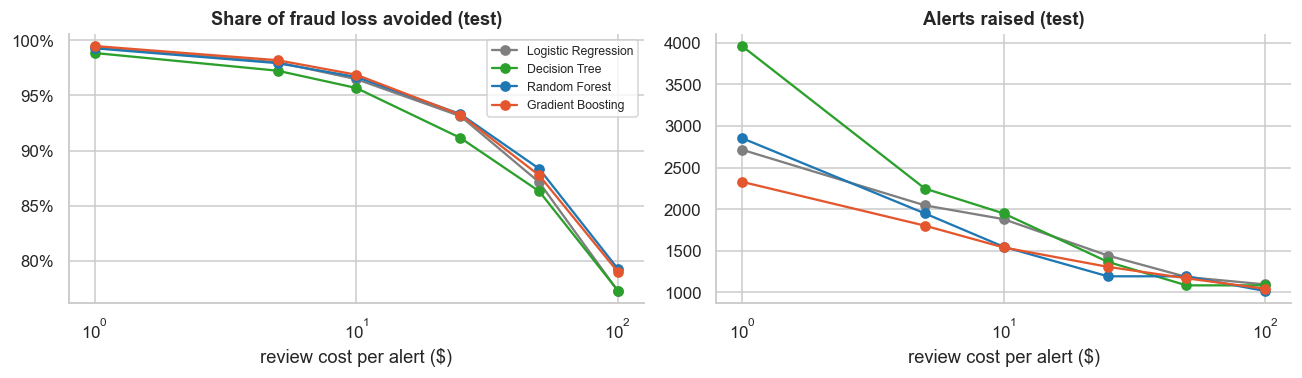

In [51]:
costs = [1, 5, 10, 25, 50, 100]
rows = []
for rc in costs:
    for m in MODELS:
        thr = cost_opt_threshold(y_va, val_scores[m], amt_va, rc)
        base = float((y_te * amt_te).sum()); c = cost_at(y_te, test_scores[m], amt_te, thr, rc)
        rows.append({"review_cost": rc, "model": m, "saved_%": (base - c) / base, "alerts": int((test_scores[m] >= thr).sum())})
sens = pd.DataFrame(rows)
display(sens.pivot(index="review_cost", columns="model", values="saved_%").style.format("{:.1%}"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for m in MODELS:
    s = sens[sens.model == m]; ax[0].plot(s.review_cost, s["saved_%"], marker="o", label=m, color=MODEL_COLORS[m]); ax[1].plot(s.review_cost, s.alerts, marker="o", color=MODEL_COLORS[m])
ax[0].set(xscale="log", xlabel="review cost per alert ($)", title="Share of fraud loss avoided (test)"); ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax[0].legend(fontsize=8)
ax[1].set(xscale="log", xlabel="review cost per alert ($)", title="Alerts raised (test)")
plt.tight_layout(); plt.show()

**Critical reading.** Savings fall as review gets more expensive (from ~99% at $1 per alert to ~77-79% at $100), and the ranking among models is stable: Gradient Boosting is best or tied at every cost level, and the Decision Tree is consistently last. The business case is therefore robust to the exact review-cost assumption, but the *size* of the benefit is not, and the number of alerts the operations team must handle falls sharply as costs rise. **Before deployment the review cost and the true cost of a false positive (customer churn, declined legitimate purchases) should be measured, not assumed.**

## 10. Conclusions, limitations and recommendations

### 10.1 Conclusions
1. **Recommended model: Gradient Boosting** (`learning_rate=0.05`, 200 iterations, 15 leaves, no class weights), best on PR-AUC, precision, recall, MCC, calibration (Brier 0.0018) and temporal stability, and fits roughly 4x faster than the Random Forest. Re-trained without age and gender it is just as accurate (0.957).
2. **Logistic Regression is a defensible, auditable fallback.** It is within ~$1.2k of the best on savings and is far easier to explain to regulators; the loss in ranking quality (0.922 vs 0.956) matters mostly for alert volume.
3. **The Decision Tree is the weakest and least stable model** and is best used as an explanation tool (its top rules reproduce the main story: large amounts and specific merchants).
4. **The Random Forest adds little over Logistic Regression here** and has poorly calibrated scores.
5. The practical gain from ML over a one-line amount rule is a reduction of roughly half in alert volume at higher recall, **not** a large increase in dollars saved.

### 10.2 Limitations (read before trusting any number)
* **Synthetic, stationary data.** Exactly 40 frauds per day, no adaptation, no bursts and no drift. Real performance will be lower, and robustness to change cannot be assessed from this data.
* **Simulator artefacts drive the signal**: merchant identity and large amounts. Real fraudsters adapt, use small test amounts and rotate merchants.
* **No rich context**: no time of day, device, location, channel or card-present flag; only one zip code in the whole dataset.
* **Cost assumptions are illustrative**: $5 per review, a caught fraud saves its full amount, no cost for customer friction or churn.
* **Single chronological split.** Intervals reflect day-to-day sampling variation, not model-training variation or a different simulation run.
* **Labels are instant and perfect**, unlike production where they are delayed and noisy.

### 10.3 Recommended next steps
1. Validate on **real, delayed-label data** with a rolling-origin backtest, and monitor weekly PR-AUC and alert rate.
2. Make the merchant signal **robust**: replace raw IDs with smoothed (shrunk) merchant-risk statistics computed from past labelled data only, and test on held-out merchants.
3. **Measure the real cost of false positives** and optimise the threshold per segment, and consider a human-review tier for medium-scoring alerts.
4. Add **richer behavioural features** (time-of-day, rolling windows, merchant novelty by peer group) once such data exist, and consider card-testing detection for small amounts.
5. Remove age/gender, and run a formal fairness audit with a larger, real dataset.
6. Calibrate scores (isotonic) if probabilities will be used downstream.

In [52]:
final = res.loc[MODELS, ["PR_AUC", "ROC_AUC", "precision", "recall", "F1", "MCC", "alerts@cost_thr", "$_saved", "saved_%"]].copy()
final["PR_AUC 95% CI"] = [f"[{ci.loc[m,'CI_low']:.3f}, {ci.loc[m,'CI_high']:.3f}]" for m in final.index]
print("Final scorecard (test window, thresholds fixed on validation):")
display(final.sort_values("PR_AUC", ascending=False).style.format({"PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "precision": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}",
        "MCC": "{:.3f}", "alerts@cost_thr": "{:,.0f}", "$_saved": "${:,.0f}", "saved_%": "{:.1%}"}))
print(f"\nSelected model: {BEST}   params: {best[BEST][1]}   features: {len(FINAL_FEATS)}")

Final scorecard (test window, thresholds fixed on validation):


,PR_AUC,ROC_AUC,precision,recall,F1,MCC,alerts@cost_thr,$_saved,saved_%,PR_AUC 95% CI
model,,,,,,,,,,
Gradient Boosting,0.9598,0.9985,0.915,0.869,0.891,0.891,"1,802","$590,601",98.2%,"[0.952, 0.967]"
Random Forest,0.9280,0.9987,0.889,0.832,0.859,0.858,"1,949","$589,013",97.9%,"[0.920, 0.938]"
Logistic Regression,0.9221,0.9985,0.848,0.838,0.843,0.841,"2,046","$589,455",98.0%,"[0.911, 0.934]"
Decision Tree,0.8778,0.9952,0.864,0.781,0.820,0.820,"2,248","$584,885",97.2%,"[0.866, 0.894]"



Selected model: Gradient Boosting   params: {'class_weight': 'balanced', 'learning_rate': 0.15, 'max_iter': 200, 'max_leaf_nodes': 15}   features: 14
